# **Analýza CO<sub>2</sub> charakteristík štátov - exploračná a zhluková analýza**
## **Projekt z predmetu ZSU, MUSIL JURAJ**

# **Úvod**

Cieľom predkladaného projektu je s využitím metód exploračnej a zhlukovej analýzy identifikovať charakteristické skupiny štátov (klastre) s podobnými hodnotami makroekonomických inditátorov a indikátorov súvisiacich s ich celkovými emisiami skleníkových plynov.
Hypotéza, ktorú by mal predpokladaný projekt potvrdiť, resp. vyvrátiť, je, že z pohľadu štruktúry ekonomiky a na to nadväzujúceho charakteru celkových emisií CO<sub>2</sub> by mali byť jasne odlíšniteľné minimálne nasledovné skupiny štátov:

- štáty ťažiace a exportujúce fosílne palivá (predovšetkým štáty Perzského zálivu a Rusko),
- vyspelé ekonomiky kladúce dôraz na zelené technológie a znižovanie emisií skleníkových plynov,
- rozvíjajúce sa ekonomiky zamerané na export (predovšetkým Čína a štáty južnej a juhovýchodnej Ázie).

Exploračná a zhluková analýza vykonaná v prvej časti tohto Projektu je zameraná práve na identifikovanie prípadných významne odlišných zoskupení štátov (na základe podobnosti resp. odlišnosti v skúmaných charakteristikách súvisiacich s ekonomikou a CO<sub>2</sub>) a porovnanie takto získaných zoskupení s predpokladanou štruktúrou štátov uvedenou vyššie.

Druhou časťou projektu (ktorá explicitne nevyplýva zo zadania) je pokus o analýzu vzťahov a časových trendov v celkových emisiách CO<sub>2</sub>) jednotlivých regionálnych zoskupení štátov (so zameraním predovšetkým na štáty EÚ vs. exportné štáty južnej a juhovýchodnej Ázie).
Hypotéza, ktorú by mal predpokladaný Projekt v tejto časti overiť, resp. vyvrátiť je, že pokles emisií CO<sub>2</sub> vo vyspelých štátov kladúcich rastúci dôraz na zelené technológie (predovšetkým v štátoch EÚ) je do určitej miery kompenzovaný presunom výroby súvisiacej s týmito emisiami do iných štátov (predpokladám štáty južnej a juhovýchodnej Ázie) a následným sekundárnym importom emisií v podobe dovážaných priemyselných produkov a tovarov.

# **Zdrojové dáta**
Ako zdroj dát som použil dataset "CO₂ Emissions Across Countries, Regions, & Sectors" (zdroj: https://www.kaggle.com/datasets/shreyanshdangi/co-emissions-across-countries-regions-and-sectors?utm_source=chatgpt.com).
Uvedený dataset obsahuje pomerne podrobné historické údaje o globálnych emisiách CO₂ a skleníkových plynov podľa krajín, regiónov, ekonomických skupín a sektorov, vrátane údajov o populácii, GDP, energetickej spotrebe a zdrojoch emisií.
Ako doplňujúci zdroj dát (pre zaradenie jednotlivých štátov do regionálnych zoskupení) som vytvoril doplňujúce zobrazenie (v podstate jednoduchú tabuľku) prideľujúcu každému štátu špecifický región.
Obidva uvedené zdroje sú uložené a verejné prístupné na nasledovných adresách na github-e:

- https://raw.githubusercontent.com/Musiljuraj/MUS0160_ZSU_Project01/refs/heads/main/Data.csv
- https://raw.githubusercontent.com/Musiljuraj/MUS0160_ZSU_Project01/refs/heads/main/Regions.csv


# **Exploračná a zhluková analýza**

Ako prvý krok som nahral vyššie spomínané datasety a údaje o regióne prislúchajúcom jednotlivým štátom (z Regions.csv) som zlúčil s hlavným datasetom (Data.csv).

Pre účely tejto analýzy som všetky štáty rozčlenil do nasledovných regiónov:
- vyspelé ekonomiky (Western-EU a Western-nonEU )
- rozvíjajúce sa exportné ekonomiky južnej a juhovýchodnej Ázie (South and Far East Asia),
- štáty s významnou ťažbou a exportom fosílnych palív (Fossil)
- zvyšné štáty (Rest of the world).

Uuvedené rozčlenenie bolo realizované s prihliadnutím na jeden z cieľov tohto projektu, ktorým je podrobná analýza skúmaných charakteristík predovšetkým pre štáty EÚ a južnej a juhovýchovnej Ázie. Z uvedeného dôvodu nebola pomerne veľká a geograficky veľmi nehomogénna skupina "Rest of the world" podrobnejšie ďalej rozčleňovaná.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

#Kaggle dataser with CO2 data
url_dataset = 'https://raw.githubusercontent.com/Musiljuraj/MUS0160_ZSU_Project01/refs/heads/main/Data.csv'

#auxiliary file with the division of countries by region
url_regions = 'https://raw.githubusercontent.com/Musiljuraj/MUS0160_ZSU_Project01/refs/heads/main/Regions.csv'

df = pd.read_csv(url_dataset)

region_df = pd.read_csv(url_regions)

# For some reason, I create Regions.csv in csv format, but with no space in between country.Region, so pandas it recognize as just one column
#after few tries I just splitted the column into the correct 'country' and 'Region' columns.
if 'country,Region' in region_df.columns:
  region_df[['country', 'Region']] = region_df['country,Region'].str.split(',', expand=True)
  region_df = region_df.drop(columns=['country,Region'])

#merge auxiliary file Regions with the main dataset, merge on 'country'
df = df.merge(region_df, left_on='Name', right_on='country', how='left')
df.rename(columns={'region': 'Region'}, inplace=True)
display(df.head())

,Description,Name,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,...,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,country,Region
0,Country,Afghanistan,1850,AFG,3752993.0,NaN,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,7.436,0.629,NaN,NaN,Afghanistan,Rest of the world
1,Country,Afghanistan,1851,AFG,3767956.0,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,0.0,7.500,0.633,NaN,NaN,Afghanistan,Rest of the world
2,Country,Afghanistan,1852,AFG,3783940.0,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,0.0,7.560,0.637,NaN,NaN,Afghanistan,Rest of the world
3,Country,Afghanistan,1853,AFG,3800954.0,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,0.0,7.620,0.641,NaN,NaN,Afghanistan,Rest of the world
4,Country,Afghanistan,1854,AFG,3818038.0,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,0.0,7.678,0.644,NaN,NaN,Afghanistan,Rest of the world


Následne som z pomerne rozsiahleho súboru charakteristík vybral tie, ktoré nejakým spôsobom súvisia s overovaním hypotéz formulovaných vyššie (t.j. predovšetkým charakteristiky súvisiace s makroekonomikou, štruktúrou energetického sektora a charakteristiky súvisiace s CO<sub>2</sub>).

Pre účely exploračnej a zhlukovej analýzy som sa obmedzil na jeden konkrétny rok, pričom rok 2019 som vybral z toho dôvodu, že ide o posledný zverejnený rok, ktorý nebol "neštandardne" ovplyvnený COVID fenoménom (ktorý okrem iných aspektov, významne ovplyvnil a skreslil aj hospodárstvo a s tým súvisiace emisie skleníkových plynov).

Následne som pre tento rok vylúčil všetky štáty, ktoré nedisponujú kompletnými definovanými hodnotami pre všetky sledované aspekty. Dôvodom prečo som namiesto odvodzovania náhradných dát zvolil ich jednoduché odstránenie sú nasledovné skutočnosti:
- analyzovaný dataset je charakteristický tým, že konkrétne štáty sa vyznačujú buď pomerne vysokým zastúpením definovaných dát alebo naopak pomerne nízkym zastúpením definovaných dát (t.j. väčšina štátov má buď dobre definované všetky údaje alebo naopak nemá definované prakticky žiadne údaje),
- chýbajúce dáta pre jednotlivé krajiny nie je dosť dobre možné zmysluplným spôsobom odvodiť a odôvodniť z dát dostupných.

Posledným krokom v tejto časti bolo doplnenie a dopočítanie nových stĺcpov:
- gdp_per_capita,
- import_co2_per_gdp,
- import_co2_per_capita.

Zatiaľčo prvý ukazovateľ (gdp_per_capita) je samovysvetľujúci, v prípade dvoch následných je potrebné krátke vysvetlenie.

Analyzovaný dataset obsahuje dve základné charakteristiky emisií CO<sub>2</sub> - "co2" (ako per_capita alebo per_gdp) a "consumption_co2" (taktiež ako per_capita alebo per_gdp). Rozdiel medzi uvedenými je v tom, že "co2" predstavuje celkové emisie CO<sub>2</sub> z územia daného štátu v dôsledku **produkcie** na území daného štátu, zatial čo "consumption_co2" predstavuje celkové emisie CO<sub>2</sub> z územia daného štátu v dôsledku **spotreby** na území daného štátu (t.j. produkcie a dovezených emisií v podobe materiálov a produktov). Rozdiel týchto dvoch hodnôt predstavuje import emisií CO<sub>2
</sub> na územie daného štátu v podobe produktov a výrobkov vyrobených na území iného štátu.

In [ ]:
#choosing interesting columns and testing how many available values are there
interestingFeatures = ['Description', 'Region', 'Name', 'year','population','gdp','co2_per_capita', 'co2_per_gdp','co2_per_unit_energy', 'energy_per_capita', 'energy_per_gdp', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'coal_co2_per_capita', 'gas_co2_per_capita', 'oil_co2_per_capita']
df_work = df[interestingFeatures]

#choosing year, the last year before the COVID crisis, which distorted trends in CO2 production somewhat
year_selected = 2019

#just drop lines with any missing values.
#any infering of missing values in this dataset are not a right choice (in my opinion) as data are in no simple way connected and there is no way how to compute or even to estimate missing ones
df_work = df_work[(df_work["Description"] == "Country") & (df_work["year"] == year_selected)].dropna()

#adding new columns - gdp_per_capita, imported CO2 per gpd and per capita (import_co2_per_gdp, import_co2_per_capita)
df_work["gdp_per_capita"] = df_work["gdp"] / df_work["population"]
df_work["import_co2_per_gdp"] = df_work["consumption_co2_per_gdp"] - df_work["co2_per_gdp"]
df_work["import_co2_per_capita"] = df_work["consumption_co2_per_capita"] - df_work["co2_per_capita"]


Zo základných štatistických charakteristík takto upraveného datasetu je zrejmé, že po uvedených úpravách a odstránení neúplných dát ostáva pre skúmaný rok 2019 k dispozícii vzorka 88 štátov.

Je potrebné uviesť, že v tomto sú obsiahnuté prakticky všetky významné štáty (významné z hľadiska absolútnych hodnôt skúmaných ukazovateľov) a že podstatnú časť odstránenej skupiny tvoria závislé územia, malé ostrovné štáty a veľmi nízko rozvinuté krajiny.

In [ ]:
#basic statistical characteristics of a data
df_work.describe()

,year,population,gdp,co2_per_capita,co2_per_gdp,co2_per_unit_energy,energy_per_capita,energy_per_gdp,consumption_co2_per_capita,consumption_co2_per_gdp,coal_co2_per_capita,gas_co2_per_capita,oil_co2_per_capita,gdp_per_capita,import_co2_per_gdp,import_co2_per_capita
count,88.0,8.800000e+01,8.800000e+01,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000
mean,2019.0,7.412527e+07,1.321863e+12,6.454261,0.241852,0.191784,36803.409091,1.295307,7.358330,0.266080,1.350966,2.162909,2.611034,27668.829414,0.024227,0.904068
std,0.0,2.140718e+08,3.343323e+12,6.002023,0.122172,0.057716,34978.182746,0.544633,6.232098,0.104196,1.866451,3.968904,2.466446,21792.867057,0.105886,3.443258
min,2019.0,5.040170e+05,1.675731e+10,0.107000,0.055000,0.041000,525.573000,0.271000,0.157000,0.029000,0.000000,0.000000,0.087000,999.206861,-0.505000,-9.533000
25%,2019.0,5.503973e+06,9.531163e+10,2.404250,0.162500,0.158750,12313.883750,0.954000,2.604750,0.195000,0.092250,0.339000,1.095250,12004.198371,-0.006250,-0.117500
50%,2019.0,1.275143e+07,3.810810e+11,4.848500,0.211500,0.194500,28197.946500,1.174000,5.920000,0.243500,0.503000,1.191500,2.192000,23485.134144,0.019000,0.297000
75%,2019.0,5.927814e+07,1.128205e+12,8.326000,0.289000,0.222750,45840.040250,1.635750,9.704500,0.319500,1.737250,2.194750,3.174000,38976.303760,0.055250,1.324250
max,2019.0,1.423520e+09,2.363190e+13,36.105000,0.643000,0.345000,207854.453000,3.332000,28.317000,0.586000,8.334000,31.248000,13.275000,133604.986835,0.488000,19.674000


Následným krokom je úvodná predbežná analýza vzájomných závislostí a prepojení medzi jednotlivým ukazovateľmi. Za týmto účelom som vytvoril:
- tzv. "scatter plot" zobrazenie všetkých dvojkombinácií vybraných ukazovateľov,
- korelačnú maticu pre všetky tieto dvojkombinácie.

(Upozornenie: vytvorenie scatter plots trvá cca 30 s. Spustenie tejto bunky nie je nevyhnutné pre fungovanie ďalších buniek.)

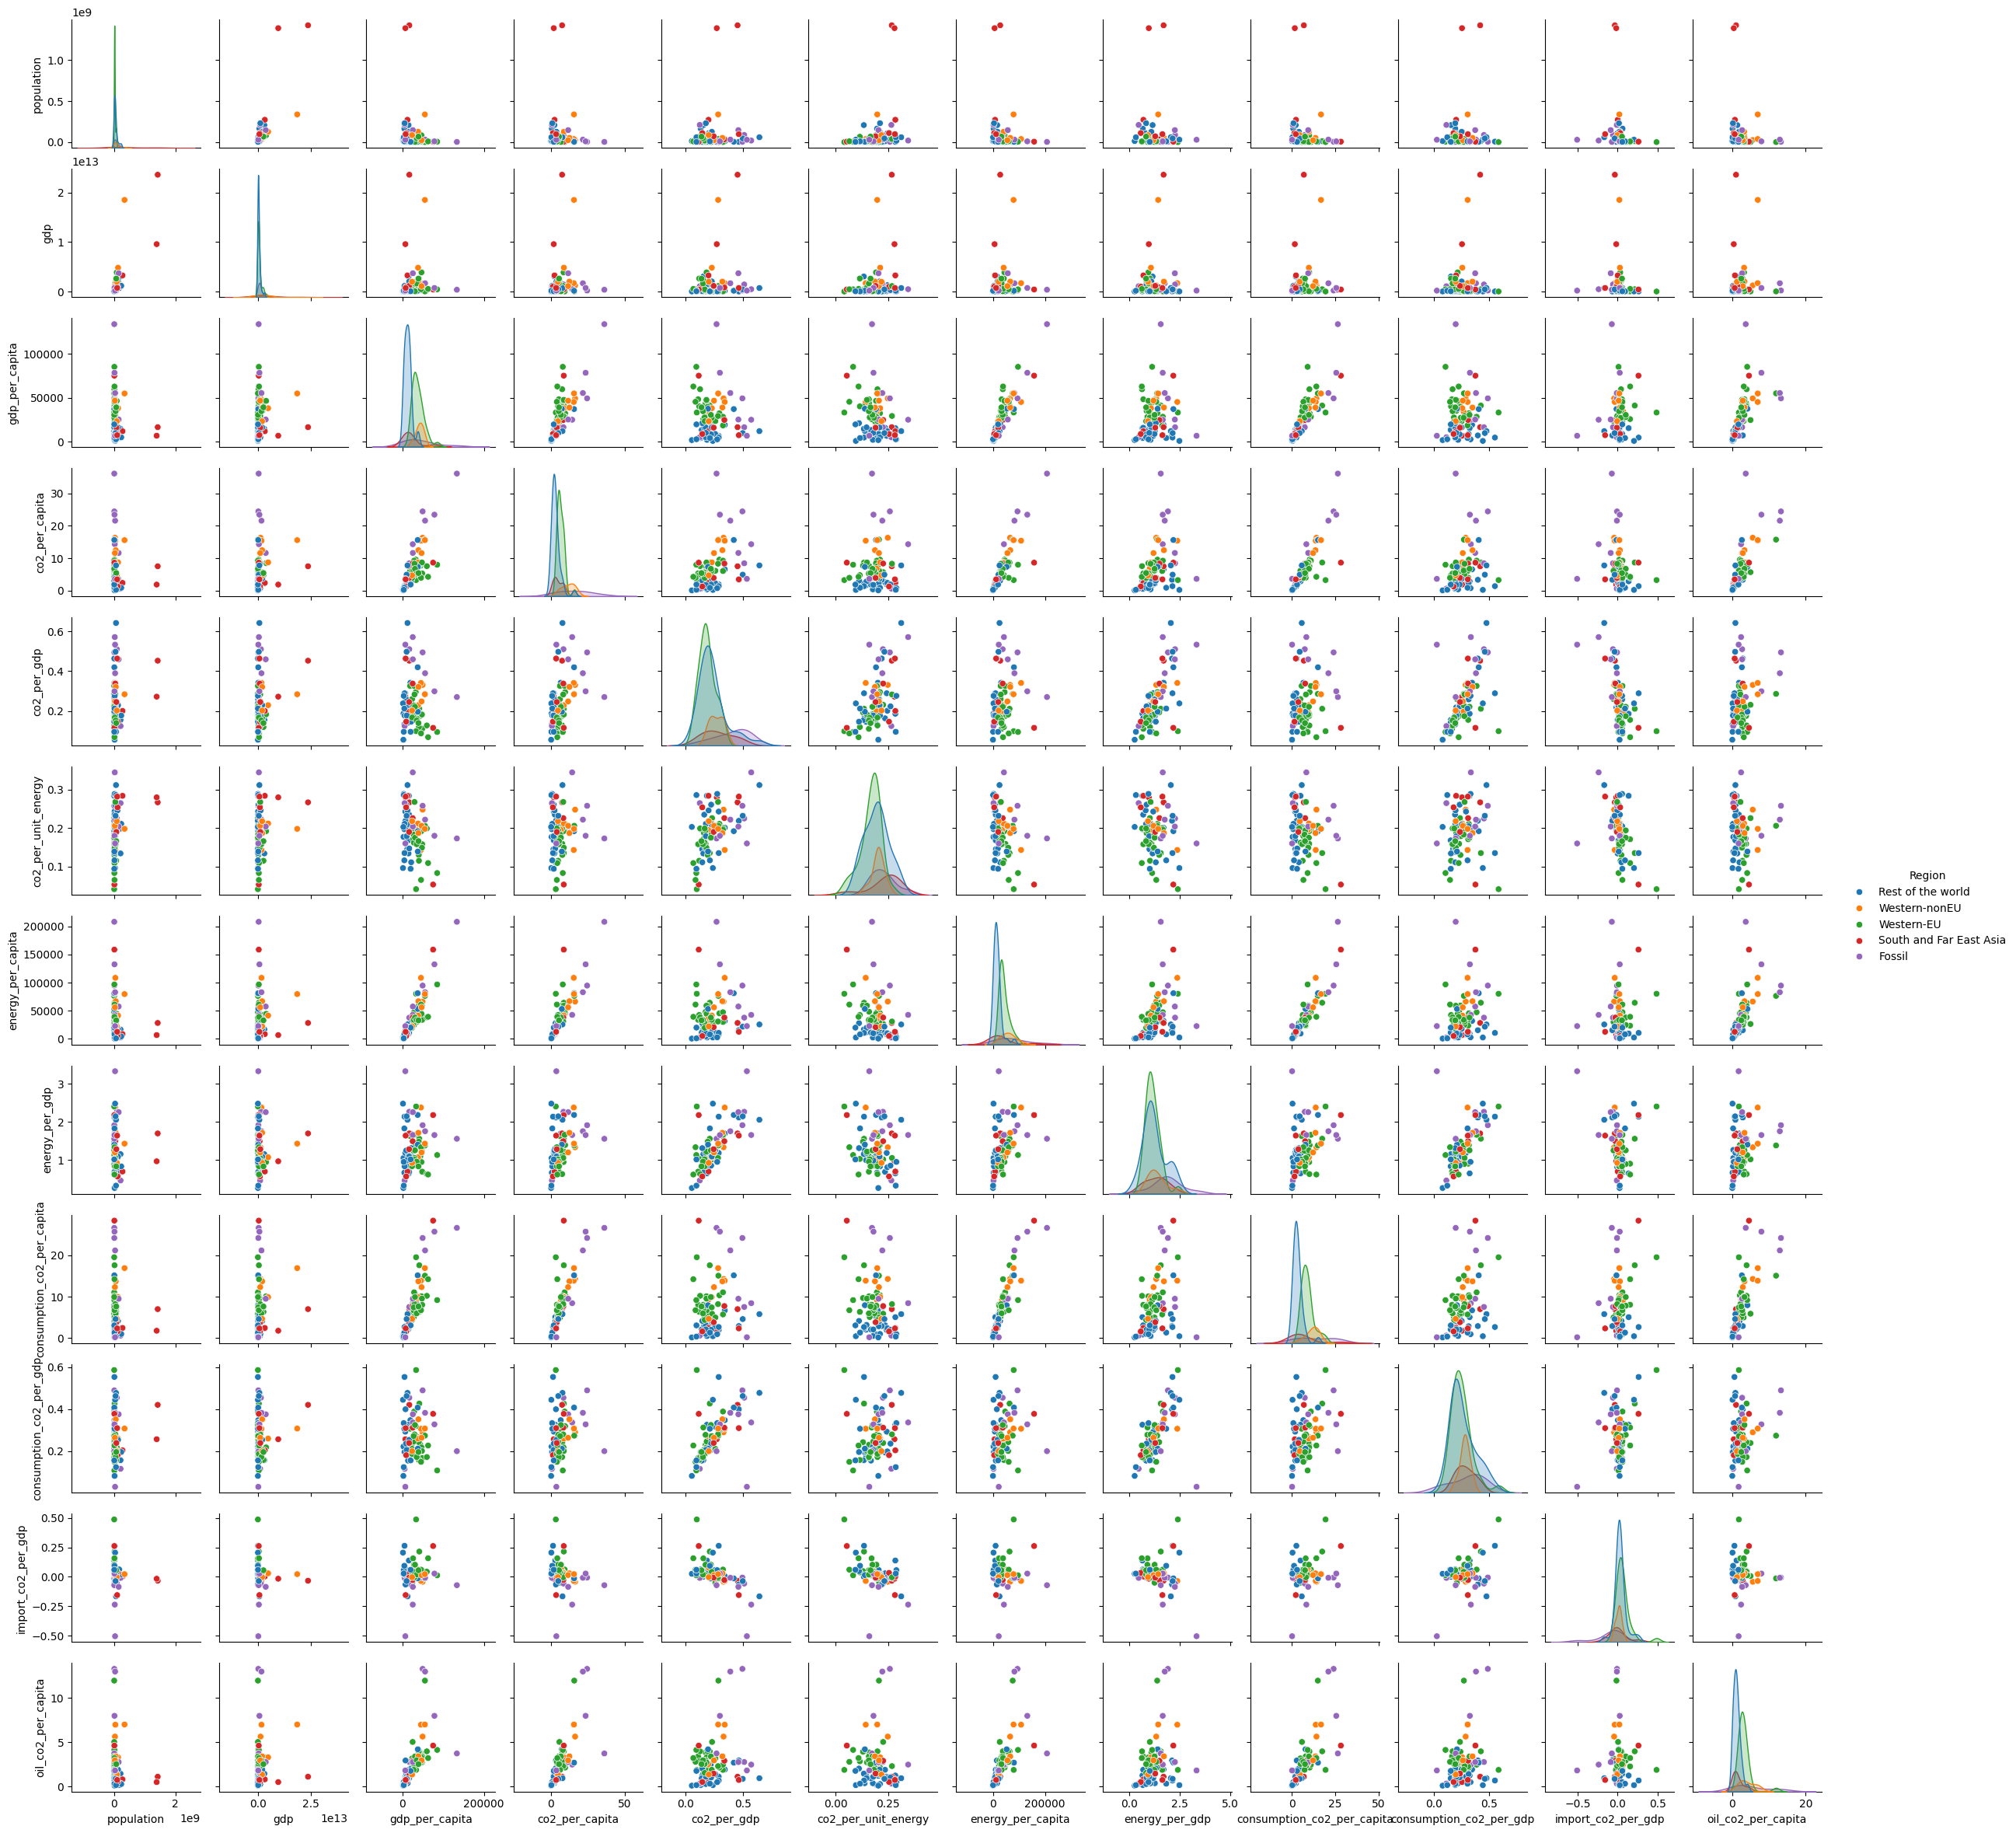

In [ ]:
#Creating pairplot for all possible combinations
selected_features_all = ['Region', 'population','gdp', 'gdp_per_capita', 'co2_per_capita', 'co2_per_gdp','co2_per_unit_energy', 'energy_per_capita', 'energy_per_gdp', 'consumption_co2_per_capita', 'consumption_co2_per_gdp','import_co2_per_gdp', 'oil_co2_per_capita']
sns.pairplot(df_work[selected_features_all], hue = 'Region', height=2)
plt.show()


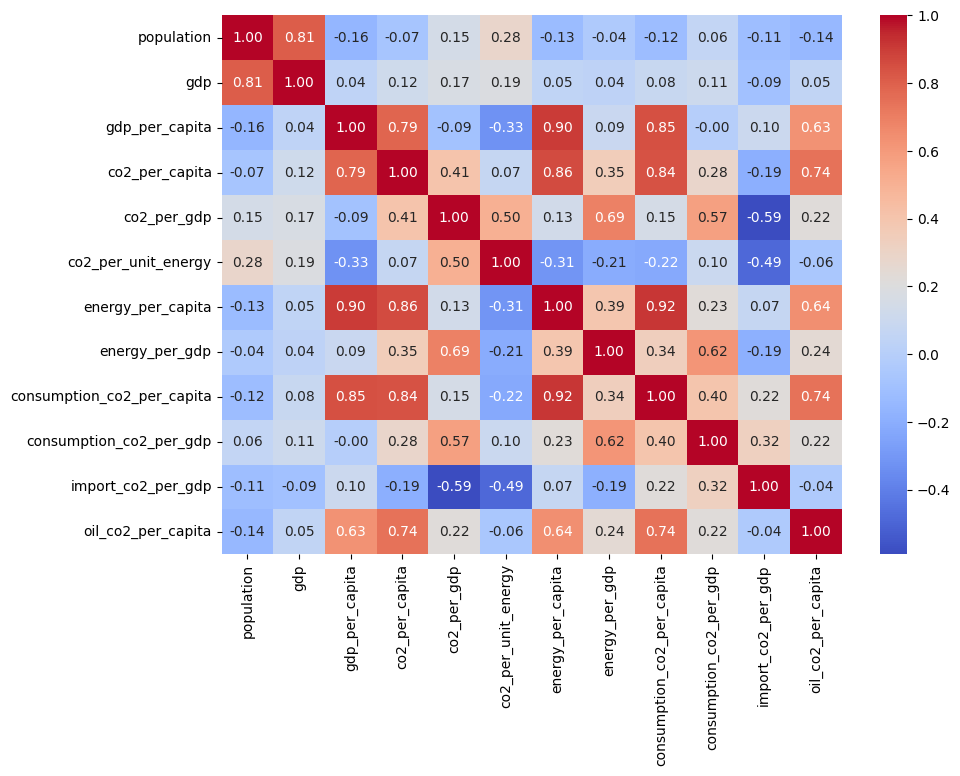

In [ ]:
selected_features_forHeatMap = ['population','gdp', 'gdp_per_capita', 'co2_per_capita', 'co2_per_gdp','co2_per_unit_energy', 'energy_per_capita', 'energy_per_gdp', 'consumption_co2_per_capita', 'consumption_co2_per_gdp','import_co2_per_gdp', 'oil_co2_per_capita']

correlation_matrix = df_work[selected_features_forHeatMap].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Na základe vyššie uvedených zobrazení a korelačnej matice som následne vybral menšiu skupinu ukazovateľov:
- ktoré priamo súvisia so skúmanou problematikou
- ktorých histogramy v "scatter plots" vykazujú významné rozdiely medzi jednotlivými regiónmi,
- pre ktoré sa v korelačnej matici nachádzajú vysoké/nízke korelačné koeficienty.

Pre túto zúženú skupinu (označenú ako selected_features_interesting ) som následne vytvoril nové (tentokrát podstatne prehľadnejšie) "scatter plot" zobrazenie.

Uvedenú skupinu ukazovateľov som následne použil aj ako vstup do zhlukovej analýzy.

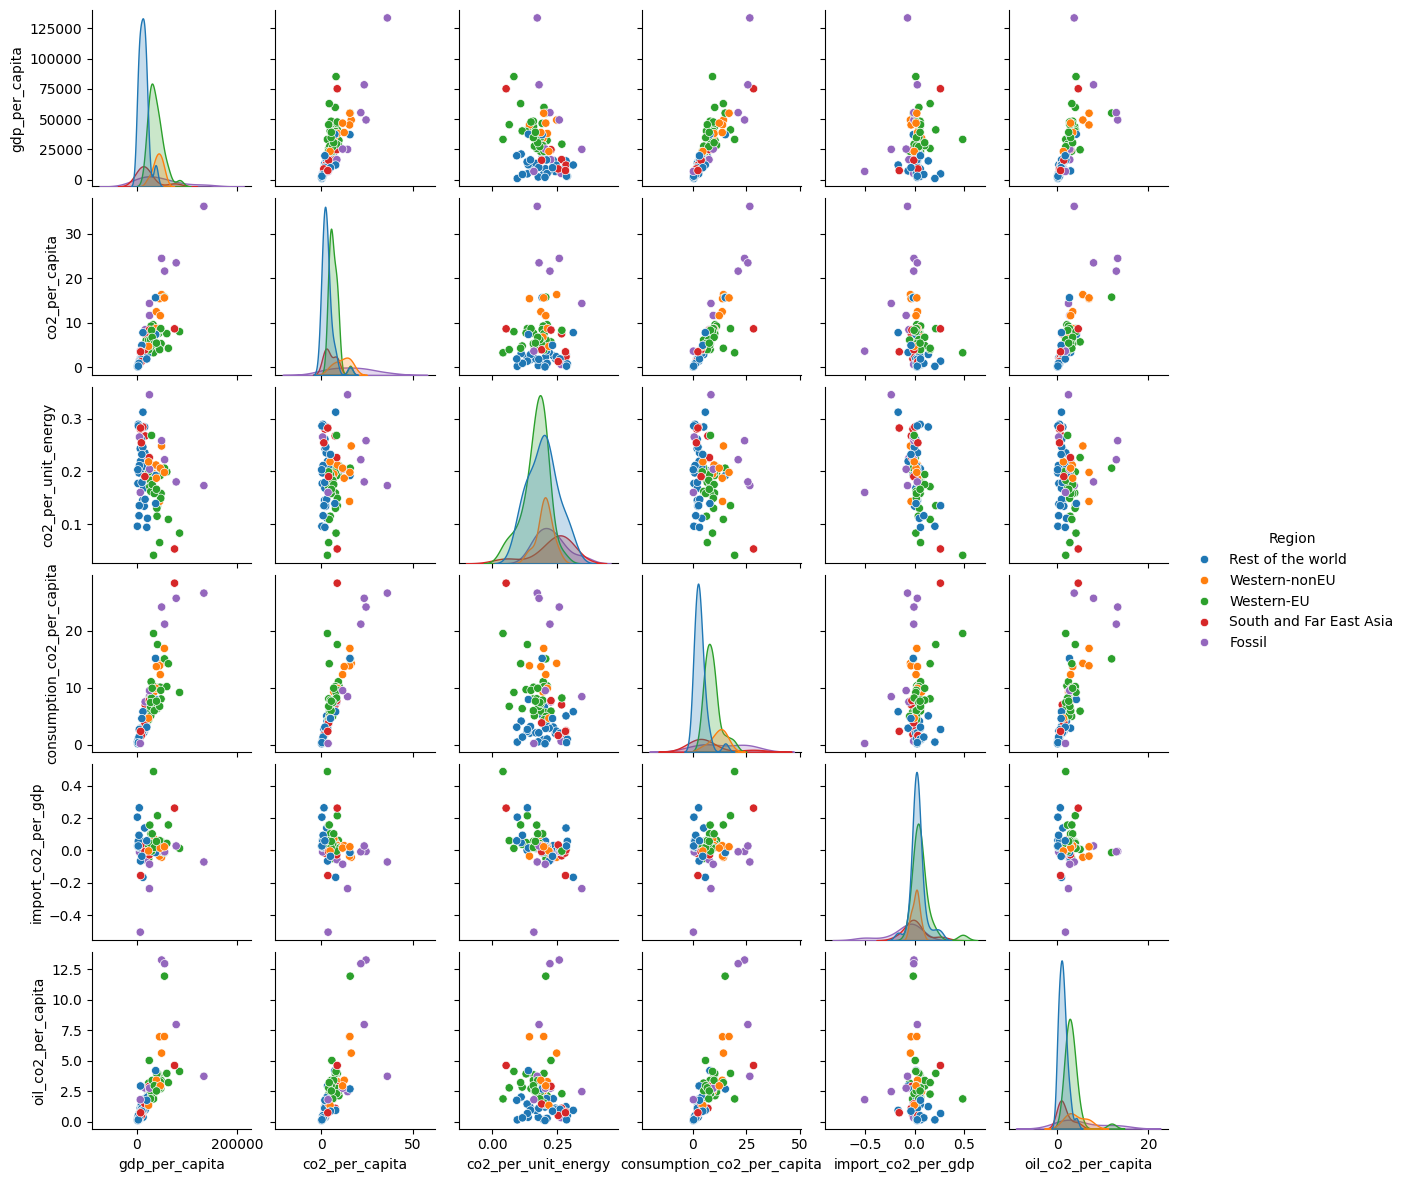

In [ ]:
#Creating pairplot for just "interesting" combinations (one that are either indispensable for CO2 analysis or shows some degree of dependence in the previous pairplots)
#I left out "absolute values", for example gdp, population and so on, since I am mainly interested in relative quantitative characteristics related to one inhabitant  (per_capita| or per unit of GDP, per_gdp)
#Included here were indicators, for which either distribution function for each regions (mainly Western vs. Asia) shows clearly different peaks = [gdp_per_capita, co2_per_capita, consumption_co2_per_capita ]
#or for which there si visible clear dependency between respective indicator and any other one, and his dependency also depend of region = [co2_per_unit_energy (dependency with oil_co2_per_capita)]
#also as there are many indicators in "double" form (per_capita and per_gdp) and "energy structure" indicator (oil_co2) is just in the form of "per_capita" I also did choose only one from each duo (understandably in per_capita form)
#So definite choice of "interesting" features for further analysis is here:
selected_features_interesting = ['Region','gdp_per_capita', 'co2_per_capita','co2_per_unit_energy', 'consumption_co2_per_capita', 'import_co2_per_gdp', 'oil_co2_per_capita']

#Repeat pairplot for better view:
sns.pairplot(df_work[selected_features_interesting], hue = 'Region', height=2)
plt.show()

Z uvedených zobrazení je zrejmé, že niektoré regionálne zoskupenia štátov sa pomerne dobre zhlukujú do odlíšiteľných zoskupení pre podstatnú časť dvojkombinácií vybraných ukazovateľov.

Vo viacerých prípadoch je pomerne jasne odlíšiteľná skupina "Western", "Fossil" a "Rest of the world".  Naopak menej je zrejmé odlíšenie skupiny "South and Far East Asia" od skupín "Western".

### **K-mean zhluková analýza**
Ako ďalší krok som v nasledovných častiach realizoval tzv. K-mean zhlukovú analýzu, pričom ako vstupné charakteristiky boli použité ukazovatele z vyššie uvedenej zúženej skupiny s označením selected_features_interesting.

Prvým krokom bolo určenie optimálneho počtu klastrov, pričom na toto určenie som použil ukazovateľ "sum of squared errors - SSE" (v kóde nižšie je tento ukazovateľ akumulovaný vo vektore "inertia") a tzv. Silhouette koeficient (akumulovaný vo vektore "silhouette").

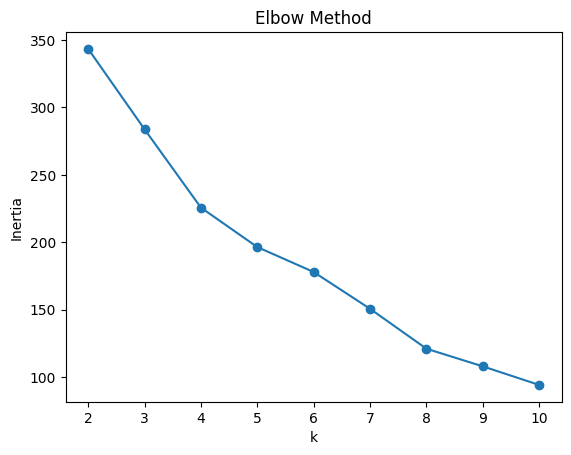

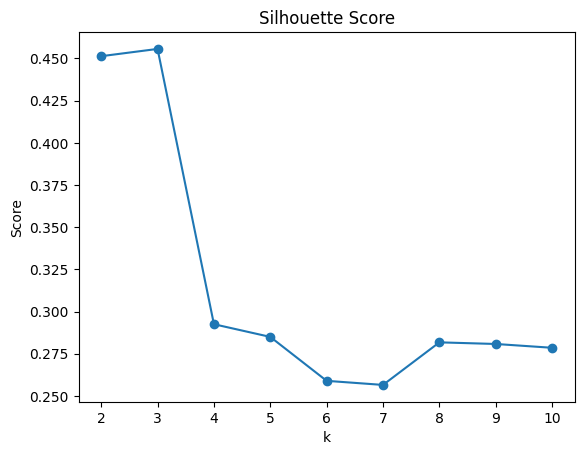

In [ ]:
#K-mean analysis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#features are identical with selected_features_interesting above, just repeats them here, for better view
features_k_mean = ['gdp_per_capita', 'co2_per_capita', 'co2_per_unit_energy', 'consumption_co2_per_capita', 'import_co2_per_gdp', 'oil_co2_per_capita']

#creating copy of dataset just for the k-mean
df_kmean = df_work[features_k_mean].copy()

#scaling numerical values
scaler = StandardScaler()
df_kmean_scaled = scaler.fit_transform(df_kmean)

#and creating indicators for quality of clustering
inertia = []
silhouette = []
K_range = range(2, 11)

#repeat K-mean for no. of clusters = 2 to 10
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=13)
    kmeans.fit(df_kmean_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(df_kmean_scaled, kmeans.labels_))

#and print indicators into the graphs
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

plt.figure()
plt.plot(K_range, silhouette, marker='o')
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')
plt.show()

Z výsledného grafického zobrazenia závislosti týchto ukazovateľov od počtu klastrov je zrejmé, že za minimálnu prípustnú voľbu je možné považovať 3 klastre.

Po vykonaní K-means zhlukovania som následne priradenie konkrétneho klastra konkrétnemu štátu pripojil do pôvodného datasetu.

Následne som zobrazil priemerné hodnoty vybraných ukazovateľov pre všetky vytvorené klastre.

In [ ]:
#Choice of number of clusters.
#From the graphs of "sum of square distances" (inertia) and Silhouette coeff. it is fairly clear, that the minimal correct number of clusters will be 3
kmeans = KMeans(n_clusters=3, random_state=42)

#add cluster designation to each country
df_work['Cluster'] = kmeans.fit_predict(df_kmean_scaled)

#basic numerical characteristics of clusters
cluster_summary = df_work.groupby('Cluster')[features_k_mean].mean()
display(cluster_summary)



,gdp_per_capita,co2_per_capita,co2_per_unit_energy,consumption_co2_per_capita,import_co2_per_gdp,oil_co2_per_capita
Cluster,,,,,,
0,13455.658864,3.822444,0.220578,3.545200,-0.015800,1.388200
1,66244.996843,19.693111,0.186778,20.645333,0.015333,8.231667
2,36269.040235,6.433147,0.155000,8.887971,0.079559,2.741676


Zo zobrazených základných charakteristík sú "v prvom nástrele", bez znalosti toho, ktorá krajina bola kam zaradená, zrejmé nasledovné skutočnosti:
- krajiny v klastry 0 sú charakteristický nízkym gdp (t.j. relatívne nízkou ekonomickou úrovňou), nízkou produkciou a nízkymi emisiami CO<sub>2</sub> na hlavu, vysokou produkciou CO<sub>2</sub> v prepočte na jednotkové množstvo energie, vývozom emisií CO<sub>2</sub> a pomerne nízkou spotrebou ropy,
- krajiny v klastri 1 sa vyznačujú veľmi vysokou úrovňou GDP (ide teda o veľmi bohaté krajiny), extrémne vysokou produkciou aj spotrebou emisií CO<sub>2</sub>, veľmi vysokou spotrebou ropy a neutrálnym charakterom exportu/importu CO<sub>2</sub>,
- krajiny v klastri 2 sa vyznačujú vysokou hodnotou GDP (ide teda o rozvinuté ale nie extrémne bohaté krajiny), stredne vysokou produkciou a spotrebou CO<sub>2</sub>, pomerne vysokou efektivitou energetickej konverzie (nízke emisie CO<sub>2</sub> na jednotku energie) a prevahou importu emisií CO<sub>2</sub>.

Aj bez znalosti konkrétneho rozdelenia je teda možné jednotlivé klastre predbežne stotožniť s nasledovnými regiónmi:
- **Klaster 0** = menej rozvinuté krajiny (v mojom rozdelení pravdepodobne "Rest of the world" a čiastočne asi "South and Far East Asia"),
- **Klaster 1** = krajiny ťažiace a vyvážajúce fosílne zdroje (v mojom rozdelení takmer určite "Fossil"),
- **Klaster 2** = vysoko rozvinuté krajiny, s vysokým importom výrobkov (takmer určite "Western-EU", pravdepodobne Western-nonEU a pravdepodobne časť "South and Far East Asia").


Pre zaujímavosť zobrazujem v nasledovnom bloku "scatter plot" zobrazenie, tentokrát ale na pozadí identifikovaných klastrov.

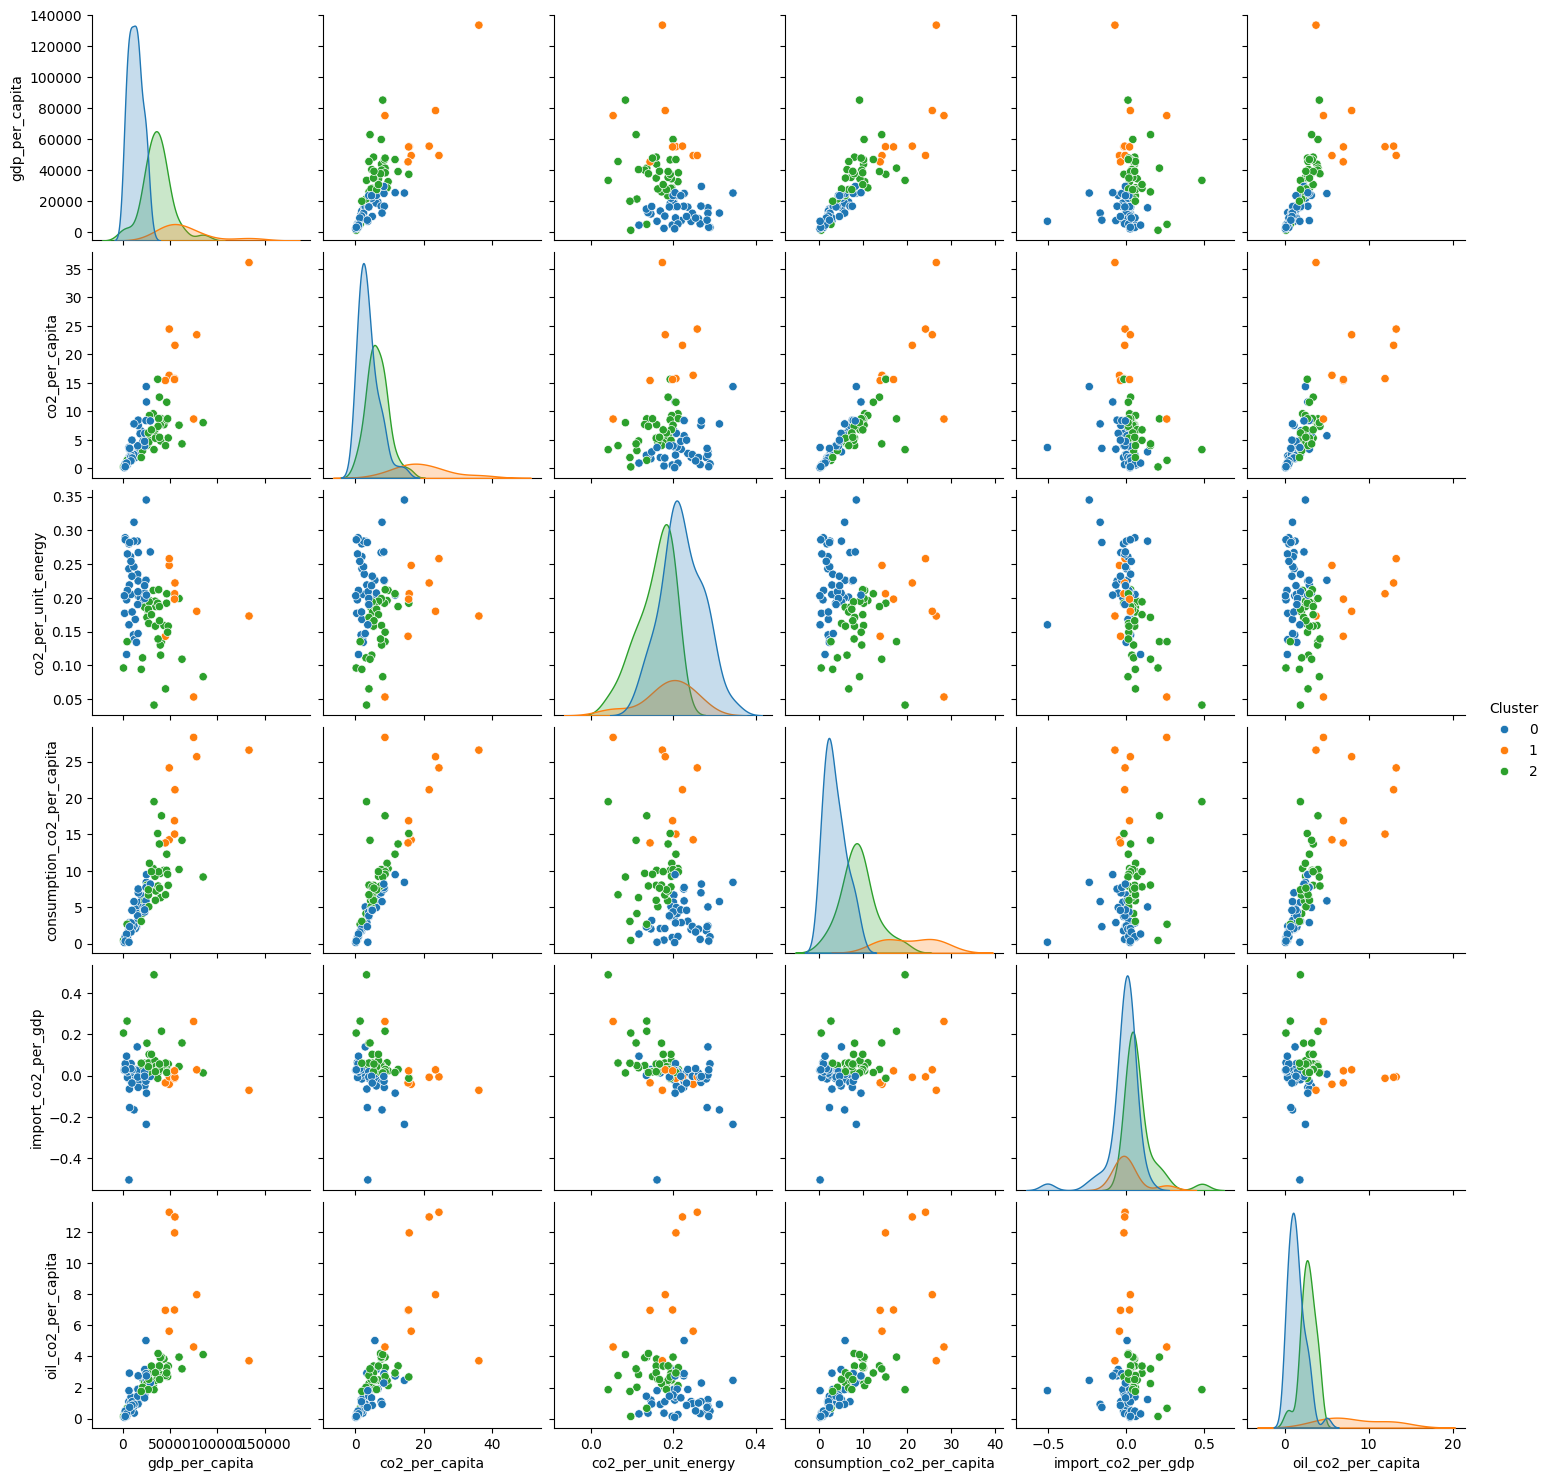

In [ ]:
#pairplots, now with clusters
sns.pairplot(df_work, vars=features_k_mean, hue='Cluster', palette='tab10')
plt.show()

Z uvedených zobrazení je zrejmé veľmi jasné zhlukovanie podľa väčšiny dvojkombinácií.

Následným krokom (opäť viac menej pre zaujímavosť a pre účely neskoršieho porovnania s hierarchickou metódou zhlukovania) uvádzam výsledky tzv. PCA analýzy.

Špecificky v tomto prípade ale pre väčšiu názornosť kombinujem zobrazenie príslušnosti ku klastru (farba bodu) s príslušnosťou k regiónu (tvar bodu).

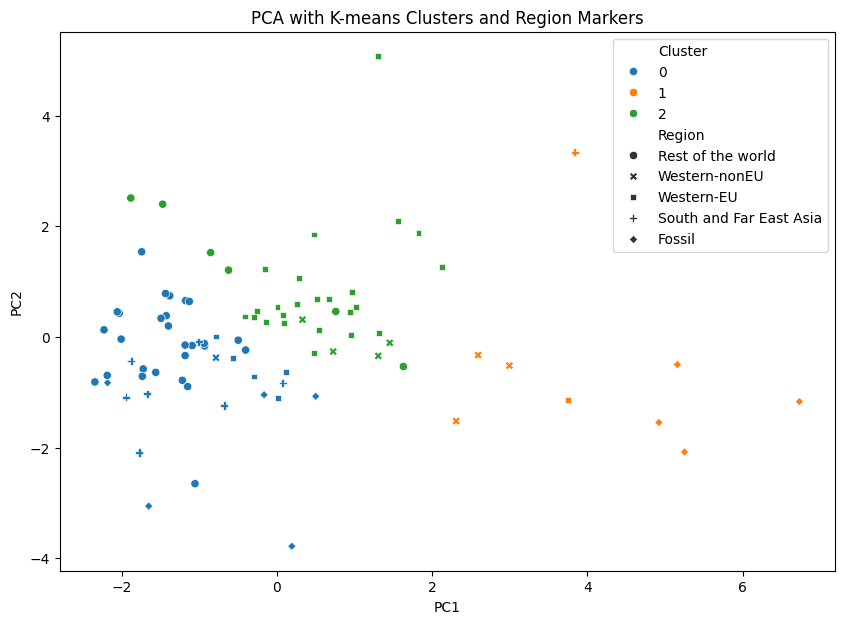

In [ ]:
#PCA visualisation of clusters vs. regional geographical groups
# just to visually inspect, how good the clustering match real regional grouping
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_kmean_scaled)
df_work['PC1'], df_work['PC2'] = df_pca[:, 0], df_pca[:, 1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_work,
    x='PC1',
    y='PC2',
    hue='Cluster',          # color = cluster
    style='Region',         # marker style = region
    palette='tab10'
)

plt.title('PCA with K-means Clusters and Region Markers')
plt.show()

Kľúčovým výsledkom K-means zhlukovej analýzy je identifikovanie konkrétneho rozdelenia krajín v jednotlivých klastroch, zobrazené v naslednom bloku.

In [ ]:
# Group countries by cluster and list their name
cluster_countries = (
    df_work.groupby('Cluster')['Name']
    .apply(list)
    .to_dict()
)

# Print countries in each cluster
for cluster, countries in cluster_countries.items():
    countries_joined = ", ".join(countries)
    print(f"Cluster {cluster}: {countries_joined}")


Cluster 0: Albania, Argentina, Armenia, Azerbaijan, Bangladesh, Belarus, Benin, Bolivia, Botswana, Brazil, Bulgaria, Chile, China, Colombia, Cyprus, Dominican Republic, Egypt, Georgia, Greece, India, Indonesia, Iran, Jamaica, Jordan, Kazakhstan, Malaysia, Mexico, Morocco, Nigeria, Pakistan, Peru, Philippines, Poland, Romania, Russia, Rwanda, Senegal, South Africa, Tajikistan, Tanzania, Thailand, Turkey, Ukraine, Venezuela, Vietnam
Cluster 1: Australia, Canada, Kuwait, Luxembourg, Qatar, Saudi Arabia, Singapore, United Arab Emirates, United States
Cluster 2: Austria, Belgium, Croatia, Czechia, Denmark, Estonia, Finland, France, Germany, Hungary, Ireland, Israel, Italy, Japan, Kyrgyzstan, Latvia, Lithuania, Malta, Mozambique, Netherlands, New Zealand, Norway, Oman, Panama, Portugal, Slovakia, Slovenia, South Korea, Spain, Sweden, Switzerland, Taiwan, United Kingdom, Uruguay


Z PCA analýzy ako aj zuvedeného rozdelenia je zrejmé, že:
- **Klaster 0** skutočne tvoria menej rozvinuté krajiny, v mojom rozdelení skupina "Rest of the world" a prekvapujúco prakticky celá skupina "South and Far East Asia" (Čína India a Vietnam), trochu prekvapujúco sa ale v tejto skupine nachádza aj Rusko, Bulharsko, Rumunsko, Grécko a napríklad aj Poľsko,
- **Klaster 1** je tvorený predovšetkým exportérmi fosílnych produktov. Okrem krajín Perského zálivu sa tu ale radia aj Kanada a Austrália a (opäť trochu prekvapujúco) aj Luxemburg a Singapur,
- **Klaster 2** je tvorený vysoko rozvinutými krajinami EÚ a toho čo sa v geopolitike pracovne označuje ako "Sever" alebo "Západ"  (prekvapením tu sú napríklad Mozambik a Kyrgyzstan).

Celkovo je možné zhodnotiť, že výsledok klastrovej analýzy pomerne dobre (s pár výnimkami) zodpovedá úvodnému predpokladu o očakávanom rozdelení jednotlivých krajín. Klastrová analýza ale nepotvrdila jasne identifikovateľné vyčlenenie krajín južnej a juovýchodnej Ázie.



V nasledovnom bloku vypočítavam špecifické priemerné charakteristiky jednotlivých klastrov, konkrétne:
- priemerný percentuálny podiel celkovo importovaného CO<sub>2</sub> z celkovo emitovaných emisií CO<sub>2</sub> (vyrobených aj dovezených),
- celkový podiel importu emisií CO<sub>2</sub> do všetkých krajín príslušného klastra z celkových celosvetových emisií CO<sub>2</sub>.

Prvý z uvedených ukazovateľov je indikátorom toho, do akej miery sa krajiny príslušného klastra snažia "outsourcovať" svoje emisie v iných krajinách.

Druhý ukazovateľ poukazuje na celkový absolútny príspevok príslušného klastra k vývozu resp. dovozu emisií (s prihliadnutím nielen na percentuálny podiel importu podľa predchádzajúceho ukazovateľa, ale aj na celkovú veľkosť ekonomiky a teda celkovú váhu krajín v klastri).

In [ ]:
#analyze the average share of imported CO2 in total CO2 emissions of the countries of the given cluster
df_work['import_to_overal_co2_ratio'] = df_work['import_co2_per_capita'] / ( df_work['co2_per_capita'] + df_work['import_co2_per_capita'])
ratio_avg = df_work.groupby('Cluster')['import_to_overal_co2_ratio'].mean()
ratio_avg_percent = ratio_avg * 100

print("\n=== Average share of imported CO2 from total CO2 emissions of countries in the cluster ===")
for cluster, value in ratio_avg_percent.items():
    print(f"Cluster {cluster}: {value:.2f}%")
print()

#analyze total percentage share of CO2 imported to each cluster from the absolute world production of CO2
#i.e. how big share of total world production was imported into a cluster
print("=== Total share of absolute world production of CO2 imported into the cluster ===")
world_total_co2 = (df_work['consumption_co2_per_capita'] * df_work['population']).sum()
df_work['import_co2_total'] = ((df_work['consumption_co2_per_capita'] - df_work['co2_per_capita']) * df_work['population'])
cluster_import_sum = (df_work.groupby('Cluster')['import_co2_total'].sum().sort_index())
cluster_import_share = cluster_import_sum / world_total_co2 * 100
for cluster, value in cluster_import_share.items():
    print(f"Cluster {cluster}: {value:.2f}%")



=== Average share of imported CO2 from total CO2 emissions of countries in the cluster ===
Cluster 0: -37.86%
Cluster 1: 1.78%
Cluster 2: 26.49%

=== Total share of absolute world production of CO2 imported into the cluster ===
Cluster 0: -4.84%
Cluster 1: 1.21%
Cluster 2: 3.34%


Z výsledkov je zrejmé, že najväčším exportérom CO<sub>2</sub> emisií prekvapujúco nie sú "fosílne" krajiny (s výnimkou Ruska) ale práve menej rozvinuté a rozvíjajúce sa krajiny, pričom najväčším prijímateľom tohto exportu sú vyspelé krajiny (skupiny "Western").

V obidvoch prípadoch tohto tvrdenie platí ako v relatívnych tak aj v absolútnych číslach.

### **Hierarchická zhluková analýza**
V ďalšom kroku (v zmysle zadania) vykonávam zhlukovú analýzu s využitím hierarchickej metódy (v tomto prípade tzv. agglomerative clustering, t.j. bottom-to-up).

Vstupnými údajmi je rovnaká množina charakteristických prvkov (ukazovateľov) aká bola použití aj pri K-mean analýze.

Prvým krokom je vytvorenie tzv. dendrogramu.

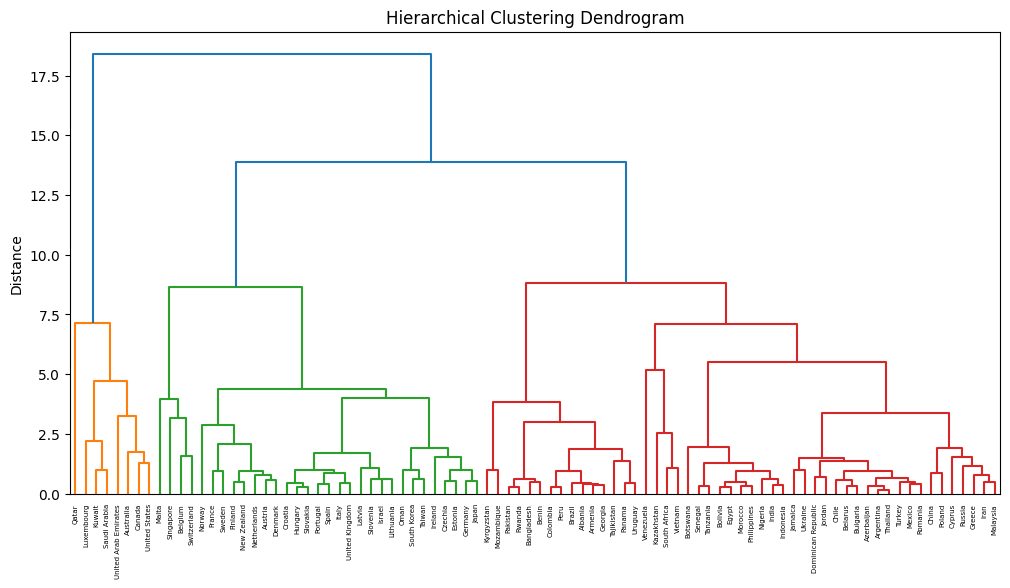

In [ ]:
#Hierarchical clustering - agglomerative (i.e. bottom-to-up)
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

#Function to Plot Dendrogram (taken from exercises)
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.ylabel('Distance')


# Compute full hierarchical tree (for dendrogram)
hier_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0,
    compute_distances=True
)

# using already scaled data from k-mean clustering part
hier_model = hier_model.fit(df_kmean_scaled)


#plot dendrogram
plt.figure(figsize=(12, 6))
plot_dendrogram(hier_model, labels=df_work["Name"].tolist())
plt.show()


Z dendrogramu je zrejmé, že aj v tomto prípade je voľba 3 klastrov akceptovateľná.

Následne som vykonal vlastné hierarchické zhlukovanie, pričom výsledné priradenie klastrov som doplnil priamo do pôvodného datasetu (ktorý teda pre každú analyzovanú krajinu obsahuje ako priradenie ku klastrom v zmysle K-mean tak aj priradenie ku klastrom v zmysle hierarchickej analýzy).

V závere tejto časti je zobrazený zoznam všetkých krajín pre jednotlivé klastre (z hierarchickej analýzy), pričom pre lepšie porovnanie je na tomto mieste opätovne zobrazený aj  zoznam všetkých krajín pre jednotlivé klastre z K-mean analýzy.

In [ ]:
#From  dendrogram it is also clear, that choice of 3 clusters is acceptable
k_cut = 3

#proceed to agglomerative clustering
hier_cut_model = AgglomerativeClustering(
    n_clusters=k_cut,
    linkage='ward'
)

# Assign hierarchical labels directly to df_work
df_work["Cluster_hier"] = hier_cut_model.fit_predict(df_kmean_scaled)

# and produce new lists of countries, now according to result of hierarchical clustering
#repeat also lists of countries,  according to k-mean clustering for comparison
cluster_countries_hier = (
    df_work.groupby("Cluster_hier")["Name"]
        .apply(list)
        .to_dict()
)
print("\n=== Countries per hierarchical clusters===")
for cluster, countries in cluster_countries_hier.items():
    countries_joined = ", ".join(countries)
    print(f"Cluster {cluster}: {countries_joined}")
print()
print("\n=== Countries per k-mean clusters===")
for cluster, countries in cluster_countries.items():
    countries_joined = ", ".join(countries)
    print(f"Cluster {cluster}: {countries_joined}")


=== Countries per hierarchical clusters===
Cluster 0: Albania, Argentina, Armenia, Azerbaijan, Bangladesh, Belarus, Benin, Bolivia, Botswana, Brazil, Bulgaria, Chile, China, Colombia, Cyprus, Dominican Republic, Egypt, Georgia, Greece, India, Indonesia, Iran, Jamaica, Jordan, Kazakhstan, Kyrgyzstan, Malaysia, Mexico, Morocco, Mozambique, Nigeria, Pakistan, Panama, Peru, Philippines, Poland, Romania, Russia, Rwanda, Senegal, South Africa, Tajikistan, Tanzania, Thailand, Turkey, Ukraine, Uruguay, Venezuela, Vietnam
Cluster 1: Australia, Canada, Kuwait, Luxembourg, Qatar, Saudi Arabia, United Arab Emirates, United States
Cluster 2: Austria, Belgium, Croatia, Czechia, Denmark, Estonia, Finland, France, Germany, Hungary, Ireland, Israel, Italy, Japan, Latvia, Lithuania, Malta, Netherlands, New Zealand, Norway, Oman, Portugal, Singapore, Slovakia, Slovenia, South Korea, Spain, Sweden, Switzerland, Taiwan, United Kingdom


=== Countries per k-mean clusters===
Cluster 0: Albania, Argentina, A

Z porovnania jednotlivých zoznamom je zrejmé, ze výstup z hierarchickej analýzy lepšie zodpovedá očakávanému rozdelenie krajín podľa ich všeobecného "zaradenia" do geografických a socio-ekonomických celkov.
Rozdelenie podľa hierarchickej analýzy predovšetkým odstraňuje niektoré "prekvapenia" spomínané pri rozdelení podľa K-mean analýzy, konkrétne:
- z Klastra 1 (Fossil) vypadol Singapur (a premiestnil sa do skupiny vyspelých ekonomík). Na druhej strane ale aj v tomto rozdelení ostáva aj naďalej Luxemburg,
- z Klastra 2 (Western)  vypadli Kyrgyzstan, Mozambik, Panama a Urugay (a premiestnili sa do Klastra 0).

Aj napriek tomu, že určité nezrovnalosti ostávajú aj pri tomto rozdelení (prítomnosť Poľska, Rumunska, Bulharska, Grécka v klastri 0), považujem hierarchické zhlukovanie (a predovšetkým teda jeho výsledky) za vhodnejšie pre tento konkrétny prípad (lepšie zachytávajúce skutočnosť).


V nasledovnej sérii buniek porovnávam výsledky zhlukovania s K-mean metódou a hierarchickým zhlukovaním aj v grafickej podobe, konkrétne v podobe "heatmap" a PCA analýzy.

Porovnanie heatmap znázorňuje v koľkých prípadoch zaradili obidve metódy jednotlivé krajiny do identických klastrov a v koľkých prípadoch do odlišných.

V prípade PCA analýzy, znázorňujem výsledky  PCA analýzy ako pre K-mean zhlukovanie tak aj pre hierarchické zhlukovanie (pre lepšie porovnanie). Vyhodnotenie tohto porovnania uvádzam hneď za uvedeným zobrazením.

In [ ]:
# Comparing results of k-mean and hierarchical clustering
# table showing cluster assignments for both methods
comparison_table = df_work[["Name", "Region", "Cluster", "Cluster_hier"]]
display(comparison_table.head(20))




,Name,Region,Cluster,Cluster_hier
343,Albania,Rest of the world,0,0
1213,Argentina,Rest of the world,0,0
1387,Armenia,Rest of the world,0,0
1561,Australia,Western-nonEU,1,1
1735,Austria,Western-EU,2,2
1909,Azerbaijan,Rest of the world,0,0
2431,Bangladesh,Rest of the world,0,0
2779,Belarus,Rest of the world,0,0
2953,Belgium,Western-EU,2,2
3301,Benin,Rest of the world,0,0


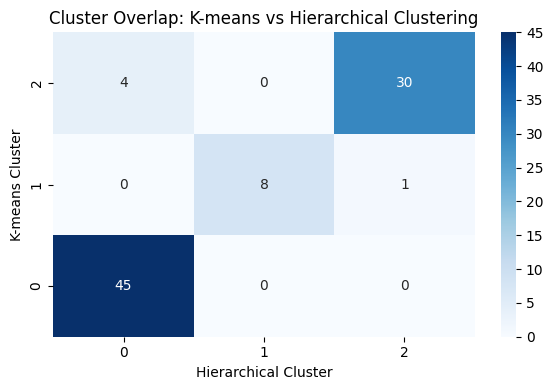

In [ ]:
# graphical representation of the differences between the methods, in form of heatmap
crosstab = pd.crosstab(df_work["Cluster"], df_work["Cluster_hier"])
crosstab = crosstab.sort_index(ascending=False)
plt.figure(figsize=(6, 4))
sns.heatmap(crosstab, annot=True, cmap="Blues", fmt="d")
plt.title("Cluster Overlap: K-means vs Hierarchical Clustering")
plt.xlabel("Hierarchical Cluster")
plt.ylabel("K-means Cluster")
plt.tight_layout()
plt.show()




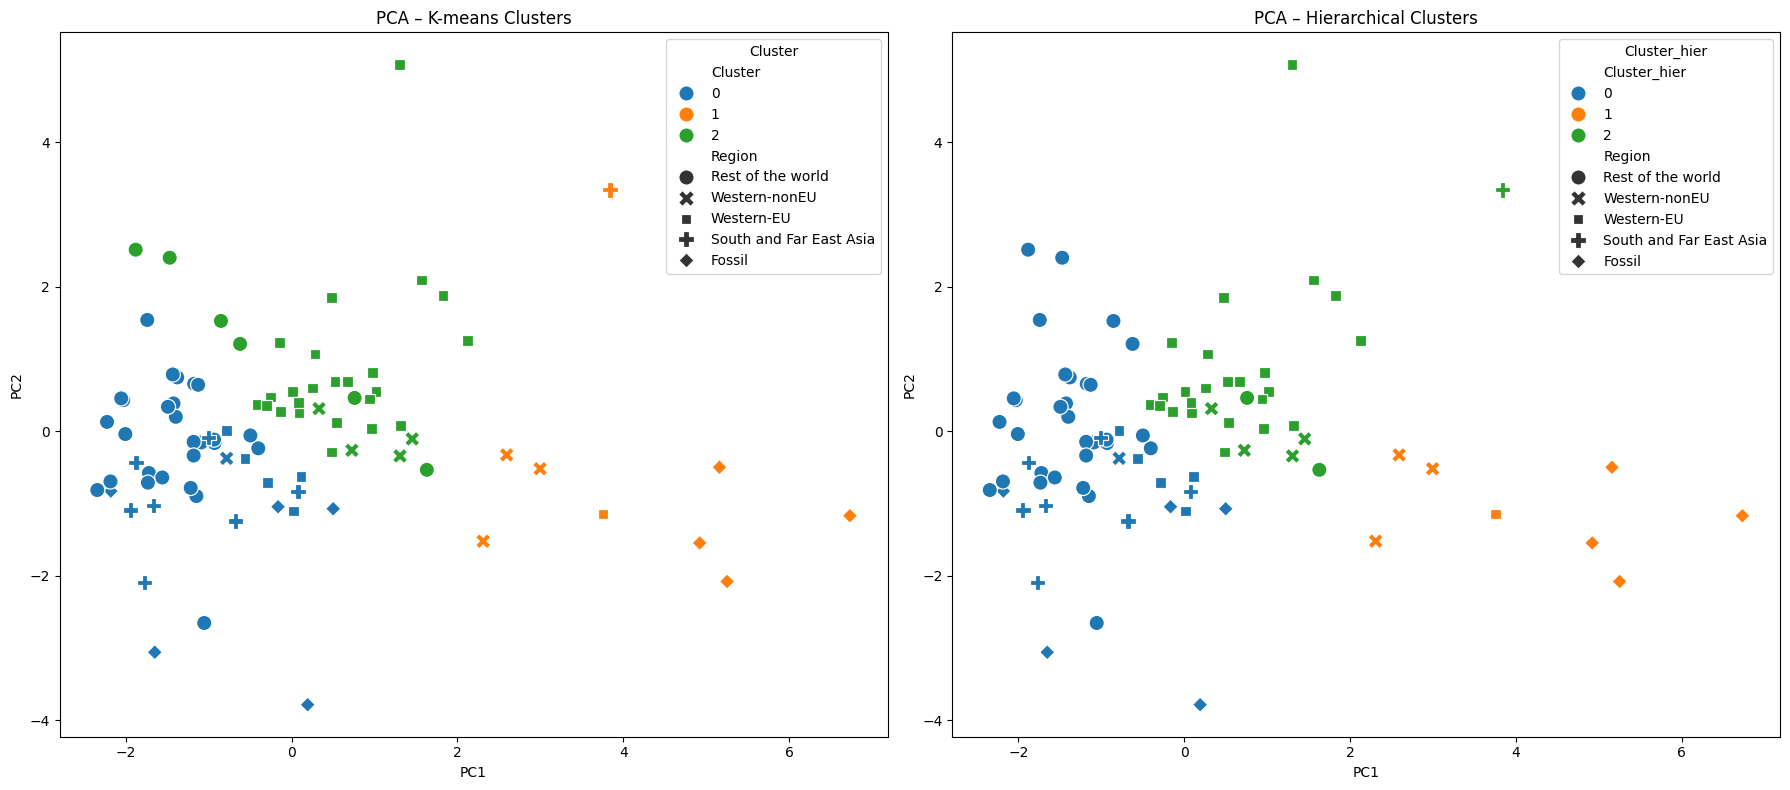

In [ ]:
# PCA visualization, side by side with previous PCA for k-mean

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#Left side: PCA with K-means
sns.scatterplot(
    ax=axes[0],
    data=df_work,
    x="PC1",
    y="PC2",
    hue="Cluster",
    style="Region",
    palette="tab10",
    s=120
)
axes[0].set_title("PCA – K-means Clusters")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title="Cluster", loc="best")

#Right side: PCA with Hierarchical Clustering
sns.scatterplot(
    ax=axes[1],
    data=df_work,
    x="PC1",
    y="PC2",
    hue="Cluster_hier",
    style="Region",
    palette="tab10",
    s=120
)
axes[1].set_title("PCA – Hierarchical Clusters")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title="Cluster_hier", loc="best")

plt.tight_layout()
plt.show()


Z výsledkov heatmap zobrazenia ako aj z porovnania PCA analýz pre obidve metódy je zrejmé, že výsledky obidvoch metód sú veľmi podobné. Ako som už uviedol v predchádzajúcich častich, považujem výsledky hierarchickej metódy za "lepšie" v tom zmysle, že lepšie vystihujú skutočné zaradenie jednotlivých krajín.

Z vyššie uvedených grafov PCA analýz je možné prehľadne vysledovať aj situáciu odlišného zariadenia pre:
- Singapur, ide o oranžový bod (Klaster 1) umiestnený vysoko hore v pravej časti grafu pre K-mean a rovnako umiestnený ale zelený bod (Klaster 2) v grafe pre hierarchickú analýzu. Z umiestnenia tohto bodu je zrejmé, že rozhodovanie o príslušnosti tohto bodu ku klastrom 1 resp. 2 je skutočne hraničné.
- Mozambik, Kyrgyzstan, Panama, Urugay, ide o 4 zelené body (v K-mean PCA) umiestnené v ľavej časti grafu na hornej hranici bodov modrého klastra a o rovnako umiestnené ale zelené 4 body v grafe pre hierarchické zhlukovanie. Aj v tomto prípade je zrejmé, že rozhodovanie je hraničné ale priradenie týchto bodov ku Klastru 0 považujem za lepšie.

V nasledovnej časti vypočítavam pre klastre získané hierarchickou analýzou vyššie spomínané charakteristiky:
- priemerný percentuálny podiel celkovo importovaného CO2 z celkovo emitovaných emisií CO2 (vyrobených aj dovezených),
- celkový podiel importu emisií CO2 do všetkých krajín príslušného klastra z celkových celosvetových emisií CO2.

a pre jednoduchšie porovnanie s výsledkami K-mean analýzy tu opätovne uvádzam aj hodnoty týchto  charakteristík pre klastre z K-mean.

In [ ]:
# Compute average share of imported CO2 from total CO2 emissions of countries in the given cluster, for the hierarchical clustering
ratio_hier = (
    df_work.groupby("Cluster_hier")["import_to_overal_co2_ratio"]
    .mean() * 100
)

# Combine it with the previously computed share for k-mean clustering
avg_table = pd.DataFrame({
    "K-means (%)": ratio_avg_percent,
    "Hierarchical (%)": ratio_hier
})

#and print results side by side
print("\n=== Average share of imported CO2 from total CO2 emissions of countries in the cluster ===")
print(avg_table)
print()

# Compute Total share of absolute world production of CO2 imported into the cluster, for the hierarchical clustering
import_hier = (
    df_work.groupby("Cluster_hier")["import_co2_total"]
    .sum() / world_total_co2 * 100
)

# Combine it with the previously computed share for k-mean clustering
import_table = pd.DataFrame({
    "K-means (%)": cluster_import_share,
    "Hierarchical (%)": import_hier
})

#and print results side by side
print("=== Total share of absolute world production of CO2 imported into the cluster ===")
print(import_table)
print()



=== Average share of imported CO2 from total CO2 emissions of countries in the cluster ===
   K-means (%)  Hierarchical (%)
0   -37.863494        -31.564725
1     1.782787         -6.679077
2    26.491567         26.225977

=== Total share of absolute world production of CO2 imported into the cluster ===
   K-means (%)  Hierarchical (%)
0    -4.836265         -4.769865
1     1.213569          0.887408
2     3.342169          3.601931





Hodnoty týchto charakteristík pre hierarchické zhlukovanie potvrdzujú závery podobné záverom z K-mean analýzy:
- najväčším exportérom CO2 emisií sú menej rozvinuté a rozvíjajúce sa krajiny,  - najväčším prijímateľom tohto exportu sú vyspelé krajiny (skupiny "Western").

Určitým rozdielom oproti záverom z K-mean analýzy je skutočnosť, že po vyradení Singapuru z klastra "Fossil" sa  z hľadiska priemerného podielu dovezených emisií CO,<sub>2</sub> štáty tejto skupiny stávajú exportérmi týchto emisií.

"Exportnosť" tejto skupiny sa ale stráca pri vyhodnotení tohto klastra ako celku, kde naopak mierne prevláda import emisií (pravdepodobne pre to, že najväčší producenti emisií v tejto skupine sú "importne" orientovaní).



### **Záverečné vyhodnotenie výsledkov EDA a zhlukovej analýzy**
S ohľadom na dôvody uvedený vyššie, som pre vytvorenie klastrov a ich súhrnné vyhodnotenie použil výsledky hierarchickej analýzy.

V nasledovnej časti sú v prehľadnej grafickej podobe (v podobe tzv. "boxplot") znázornené všetky hodnotené charakteristiky pre jednotlivé identifikované klastre.

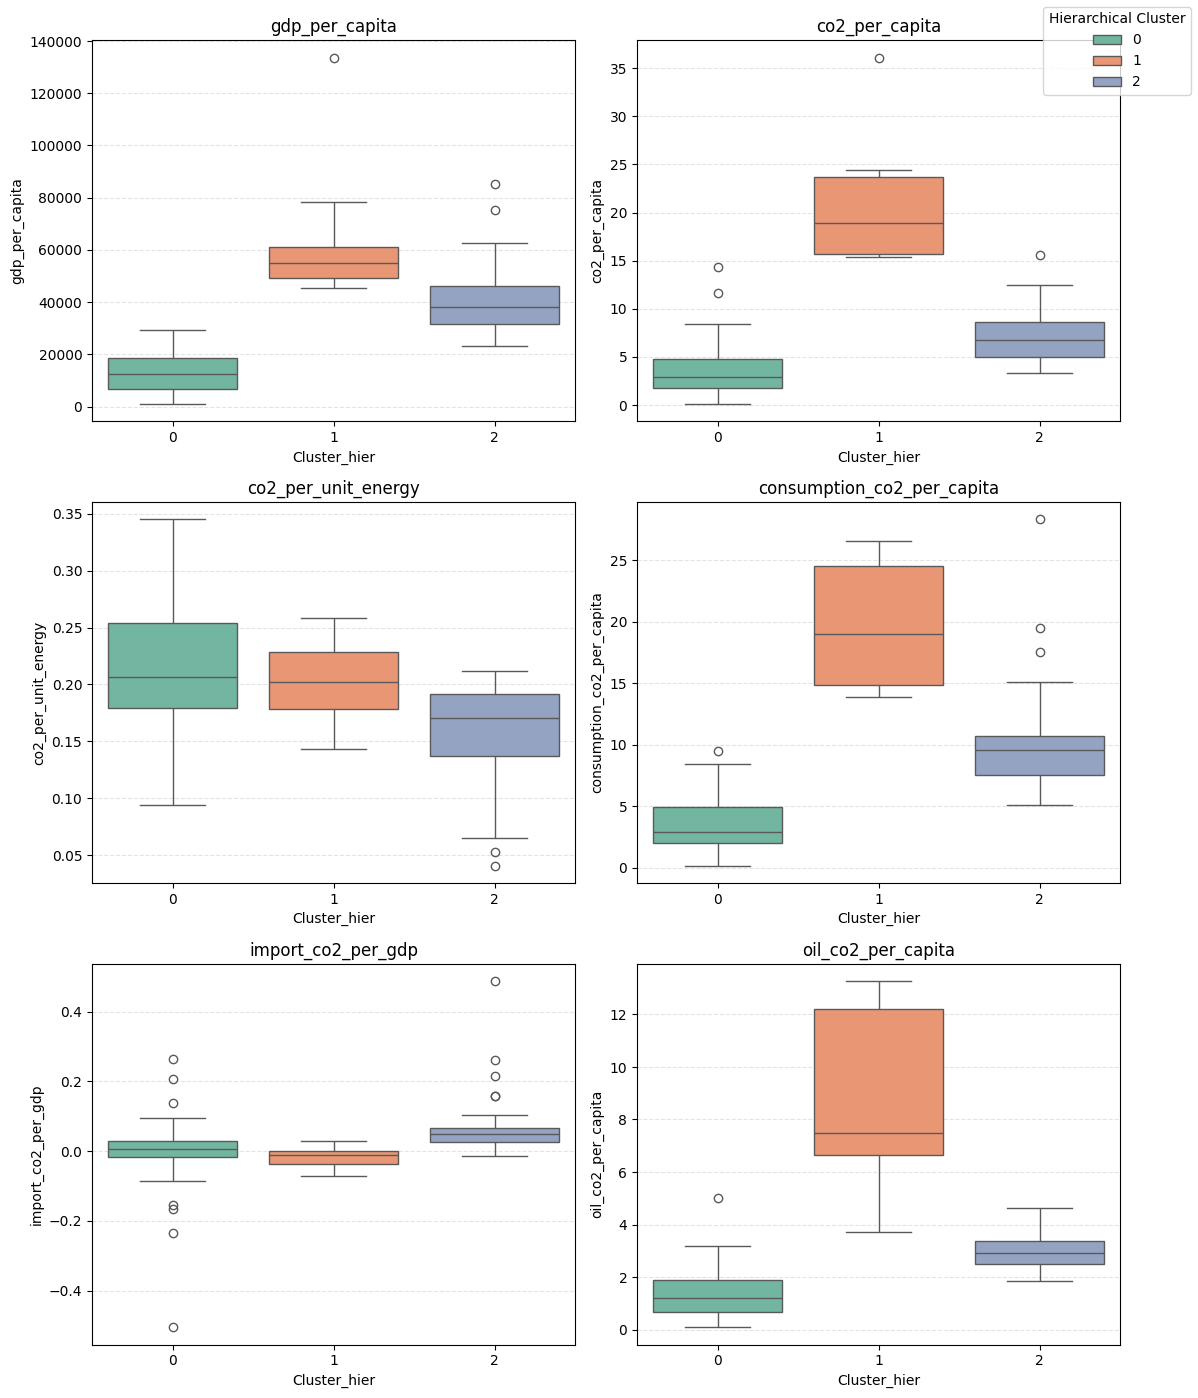

In [ ]:
#Considering the main topic of this analysis, which is the contribution of countries to the global CO2 balance, hierarchical clustering can be considered more appropriate.
# Here is the main comparison of country characteristics in individual clusters
#
# ============================================================

# Number of subplots
n_features = len(features_k_mean)

# Create figure with 6 subplots (3×2 grid)
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

# iterate through features and plot on subplots
for ax, feature in zip(axes, features_k_mean):
    sns.boxplot(
        data=df_work,
        x="Cluster_hier",
        y=feature,
        hue="Cluster_hier",
        palette="Set2",
        ax=ax
    )

    ax.set_title(f"{feature}", fontsize=12)
    ax.set_xlabel("Cluster_hier")
    ax.set_ylabel(feature)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

# Remove duplicate legends from all subplots
for ax in axes:
    ax.get_legend().remove()

# Create ONE shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Hierarchical Cluster", loc="upper right")

plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave space for legend on the right
plt.show()


#### **Vyhodnotenie a súhrnná charakteristika identifikovaných skupín**
Zo zobrazených výsledkov je zrejmé, že všetky hodnotené krajiny tvoria tri  pomerne výrazné zoskupenia, charakterizovateľné nasledovne:

**Klaster 0**
- nízka úroveň GDP (t.j. nízka životné úroveň),
- nízka úroveň produkcie a spotreby emisií CO<sub>2</sub>,
- nízka miera "CO<sub>2</sub>" efektivity v energetike (ktorá je nevyhnutne dôsledkom nízkej celkovej "energetickej" efektivity a teda reltívneho, technologického zaostávania v energetickom sektore),
 - relatívne nízka produkcia/spotreba ropy (v prepočte na obyvateľa).

 Trochu prekvapujúcou je mierne pozitívna hodnota ukazovateľa "import_co2_per_gdp", ktorá implikuje "CO<sub>2</sub> importnosť" a teda prevahu dovozu emisií CO<sub>2</sub> nad ich vývozom, čo je v priamo rozpore so skutočnosťou, že vyššie vypočítané hodnoty indikujú, že táto skupina by mala byť najväčším exportérom emisií CO<sub>2</sub> a to ako v relatívnych tak aj v absolútnych číslach.

 Uvedený rozpor sa ale vyjasní v momente keď sa pozrieme na situáciu s odľahlými hodnotami pre tento ukazovateľ v nasledujúcich tabuľkách (viď tabuľky nižšie).

 Z uvedeného je zrejmé, že na strane "exportných extrémov" sú práve najľudnatejšie krajiny nielen z tejto skupiny ale v rámci celého sveta (predovšetkým Čína, India a Rusko), zatial čo na strane "importných extrémov" sú podstatne menšie krajiny.

 Celkovo je teda uvedený klaster možné charakterizovať ako relatívne chudobné a rozvíjajúce sa ekonomiky, zamerané na priemyselnú výrobu pre zvyšok sveta (teda proexportné ekonomiky).


In [ ]:
# largest CO2 exporters in cluster 0

df_work[df_work["Cluster_hier"] == 0].nsmallest(
    5,
    "import_co2_total"
)


,Description,Region,Name,year,population,gdp,co2_per_capita,co2_per_gdp,co2_per_unit_energy,energy_per_capita,...,oil_co2_per_capita,gdp_per_capita,import_co2_per_gdp,import_co2_per_capita,Cluster,PC1,PC2,import_to_overal_co2_ratio,import_co2_total,Cluster_hier
6259,Country,South and Far East Asia,China,2019,1.423520e+09,2.363190e+13,7.526,0.453,0.267,28264.688,...,1.096,16601.027118,-0.033,-0.549,0,-0.676714,-1.243083,-0.078687,-7.815127e+08,0
25398,Country,Fossil,Russia,2019,1.465331e+08,3.705040e+12,11.636,0.460,0.204,57430.348,...,2.749,25284.669031,-0.085,-2.160,0,0.501313,-1.073532,-0.227944,-3.165114e+08,0
13741,Country,South and Far East Asia,India,2019,1.389030e+09,9.595460e+12,1.881,0.272,0.280,6736.512,...,0.487,6908.027837,-0.016,-0.115,0,-1.943992,-1.090703,-0.065119,-1.597385e+08,0
28530,Country,Rest of the world,South Africa,2019,5.958788e+07,7.216420e+11,7.789,0.643,0.312,25577.125,...,0.926,12110.549998,-0.166,-2.017,0,-1.054396,-2.654427,-0.349446,-1.201888e+08,0
15481,Country,Fossil,Kazakhstan,2019,1.920956e+07,4.812460e+11,14.331,0.572,0.345,42588.301,...,2.463,25052.427032,-0.236,-5.916,0,0.193372,-3.785302,-0.703030,-1.136437e+08,0


In [ ]:
# largest CO2 importers in cluster 0
df_work[df_work["Cluster_hier"] == 0].nlargest(
    5,
    "import_co2_total"
)

,Description,Region,Name,year,population,gdp,co2_per_capita,co2_per_gdp,co2_per_unit_energy,energy_per_capita,...,oil_co2_per_capita,gdp_per_capita,import_co2_per_gdp,import_co2_per_capita,Cluster,PC1,PC2,import_to_overal_co2_ratio,import_co2_total,Cluster_hier
19656,Country,Rest of the world,Mexico,2019,125762977.0,2.047700e+12,3.723,0.229,0.209,17919.082,...,1.893,16282.216347,0.024,0.399,0,-0.935753,-0.116358,0.096798,5.017943e+07,0
2431,Country,Rest of the world,Bangladesh,2019,164913060.0,7.172150e+11,0.575,0.132,0.197,2914.894,...,0.153,4349.049129,0.063,0.274,0,-2.030794,0.429269,0.322733,4.518618e+07,0
24528,Country,South and Far East Asia,Philippines,2019,110804685.0,9.861150e+11,1.295,0.146,0.254,5128.804,...,0.500,8899.578569,0.034,0.303,0,-1.877331,-0.437280,0.189612,3.357382e+07,0
23310,Country,Rest of the world,Pakistan,2019,230800909.0,1.172330e+12,0.900,0.177,0.211,4400.116,...,0.268,5079.399406,0.018,0.089,0,-2.005722,-0.039623,0.089990,2.054128e+07,0
13915,Country,South and Far East Asia,Indonesia,2019,272489379.0,3.272570e+12,2.399,0.200,0.284,8530.325,...,0.795,12009.899292,0.003,0.040,0,-1.668455,-1.026411,0.016400,1.089958e+07,0


**Klaster 1**

- veľmi vysoká úroveň GDP (t.j. veľmi vysoká životné úroveň, bohaté krajiny),
- veľmi vysoká produkcia aj spotreba emisií CO<sub>2</sub>,
- pomerne nízka miera "CO<sub>2</sub>" efektivity v energetike a teda pomerne vysoká energetická náročnosť energetického sektora,
 - veľmi vysoká produkcia ropy (vysoko pravdepodobne určenej predovšetkým na export).

  Klaster je zreteľne identifikovateľný ako krajiny zameraná na export fosílnych zdrojov (s výnimkou Luxemburgu, v tomto prípade ide ale o extrémne proexportnú ekonomiku).


  **Klaster 2**

  - relatívne vysoká úroveň GDP (t.j. relatívne vysoká životné úroveň, bohaté krajiny),
- pomerne vysoká produkcia aj spotreba emisií CO<sub>2</sub>,
- veľmi vysoká miera "CO<sub>2</sub>" efektivity v energetike a teda  nízka energetická náročnosť energetického sektora (vysoká technologický vyspelosť tohto sektora a zameranie na nefosílne zdroje v podobe jadra, hydroenergetiky a alternatívnych zdrojov), s uvedeným súvisí aj relatívne nízka produkcia / spotreba ropy,
 - jasne "pro importné" zameranie (výrazný import emisií CO<sub>2</sub>).

 Klaster je zreteľne stotožniteľný s krajinami EÚ a "prozápadne" orientovanými ekonomikami vo svete (Taiwan, Izrael a pod.).

### **Stručné záverečné zhrnutie EDA a zhlukovej analýzy**
Zo záverov analýzy je zrejmé čiastočné potvrdenie úvodnej hypotézy. Potvrdilo sa zreteľné rozčlenenie na "exportérov CO<sub>2</sub>" a"importérov CO<sub>2</sub>". Rovnako sa potvrdilo zreteľné vyčlenenie exportérov fosílnych palív. Naopak nepotvrdilo sa samostatne zreteľné vyčlenenie krajín južnej a juhovýchodnej Ázie ako výlučnej celosvetovej "priemyselnej výrobne".

K uvedenému je možné vysloviť ďalšiu hypotézu, že takéto "rozplývanie"  krajín tohto regiónu medzi ostatnými krajinami celého sveta je dôsledkom globalizácie celkovej priemyselnej výroby. Túto hypotézu už ale v tomto Projekte overovať nebudem.

## **Analýza trendov v exporte a importe CO<sub>2</sub>**

Táto doplňujúca časť Projektu nevyplýva priamo zo zadania, je ale kľúčovým dôvodom prečo som si vybral predmetný dataset na analýzu.

Zo všeobecne dostupných zdrojov a s prihliadnutím na moje osobné pracovné skúsenosti (environmentálne poradenstvo pre priemysel) je možné vysloviť hypotézu (formulovanú aj v úvode tohto projektu) že pokles emisií CO<sub>2</sub> v krajinách EÚ nie je v celosvetovom meradle čisto absolútnym poklesom, ale čiastočne len obyčajným presunom priemyselnej výroby a s tým súvisiacich emisií do iných krajín. Autor sa totižto aj v priestore Slovenskej republiky v praxi stretol s konkrétnymi prípadmi uzatvárania energeticky náročných prevádzok a presunom ich výroby do krajín mimo EÚ, pričom dopyt Slovenskej republiky po produktoch tohto priemyslu neklesol.

Kľúčovou otázkou, ktorú by som chcel v tejto časti zodpovedať je do akej miery je tento pokles nahradený dovozom a predovšetkým aký je historický vývoj a trendy tohto procesu.

### **Metodika**
Za týmto účelom v tejto časti analyzujem nasledovné trendy viacerých ukazovateľov prítomných vo zvolenom datasete, pre vybrané regíony EÚ a South and Far East Asia (pričom pre referenciu pridávam aj skupinu Western-nonEU, ktorá predstavuje ekonomiky podobného typu ako štáty EÚ ale s výrazne menším dôrazom na "zelené opatrenia") :

**Trendy v makroekonomických ukazovateľov**

V tejto skupine sú ukazovatele  GDP, veľkosť populácie a GDP per capita ako najdôležitejšie ukazovatele absolútnych zmien v sledovaných regiónoch.


**Trendy v absolútnych CO<sub>2</sub> emisiách a ich exporte / importe**

V tejto skupine sú predovšetkým ukazovatele celkových emisií (v dôsledku produkcie a spotreby) pre sledované regióny, ako najdôležitejších indikátorov celkového vplyvu a príspevku daného regiónu.

Rovnako sa tu nachádzajú aj ukazovatele celkového absolútneho importu aj jeho relatívneho podielu na celkovej spotrebe. Práve tento druhý ukazovateľ je podľa môjho názoru najdôležitejším indikátorom miery, do akej príslušný región presúva emisie CO<sub>2</sub> do iného regiónu, namiesto toho aby ich skutočne znižoval.

Negatívny trend v tomto ukazovateli teda bude indikovať znižovanie tejto nepriaznivej závislosti, zatial čo pozitívny trend naopak jej zväčšovanie.







In [ ]:
# Analysis of main trends in CO2 characteristics
# Preliminary calculations and preparation of data and time series
df_trends = df[(df["Description"] == "Country") & df["year"].notna()].copy()

# Regions of interest for analysis
regions_of_interest = [
    "World",
    "Western-EU",
    "Western-nonEU",
    "South and Far East Asia"
]

# Colors for consistent plotting (same color for specific region in each graph)
region_colors = {
    "World": "black",
    "Western-EU": "blue",
    "Western-nonEU": "green",
    "South and Far East Asia": "red"
}

# Analyzed interval 2012- 2022
df_2012_2022 = df_trends[(df_trends["year"] >= 2012) & (df_trends["year"] <= 2022)].copy()

# Compute total production of CO₂ in absolute numbers
df_2012_2022.loc[:, "production_co2_total"] = (
    df_2012_2022["co2_per_capita"] * df_2012_2022["population"]
)
# Compute total consumption of CO₂ in absolute numbers
df_2012_2022.loc[:, "consumption_co2_total"] = (
    df_2012_2022["consumption_co2_per_capita"] * df_2012_2022["population"]
)

# Compute total imported CO₂ in absolute numbers
df_2012_2022.loc[:, "import_co2_total"] = (
    df_2012_2022["consumption_co2_total"] - df_2012_2022["production_co2_total"]
)
# Compute total exported CO₂ in absolute numbers
df_2012_2022.loc[:, "export_co2_total"] = (
    df_2012_2022["production_co2_total"] - df_2012_2022["consumption_co2_total"]
)

# Compute absolute value of imported CO2, per unit of GDP
df_2012_2022.loc[:, "import_co2_per_gdp"] = (
    df_2012_2022["consumption_co2_per_gdp"] - df_2012_2022["co2_per_gdp"]
)

#Compute share (percentage) of imported CO2 from total CO2 consumption, per unit GDP
df_2012_2022.loc[:, "import_to_overal_co2_ratio_gdp"] = (
    df_2012_2022["import_co2_per_gdp"] /
    (df_2012_2022["co2_per_gdp"] + df_2012_2022["import_co2_per_gdp"])
)

# Create time series for consumption_co2_per_gdp and  co2_per_unit_energy for three regions of interest
df_hist = df_2012_2022[df_2012_2022["Region"].isin(["Western-EU", "Western-nonEU", "South and Far East Asia"])]
df_hist_grouped = (
    df_hist.groupby(["Region", "year"])[["consumption_co2_per_gdp", "co2_per_unit_energy"]]
    .mean()
    .reset_index()
)

# Create time series for gdp, population, gdp per capita and consumption_co2_total for whole world
world_gdp = df_2012_2022.groupby("year")["gdp"].sum()
world_pop = df_2012_2022.groupby("year")["population"].sum()
world_gdp_pc = world_gdp / world_pop
world_co2_cons = df_2012_2022.groupby("year")["consumption_co2_total"].sum()

# "Graph displaying dispatcher": return specific time series for each region and characteristic specified by caller
def region_series(region_name, column):
    if region_name == "World":
        if column == "gdp": return world_gdp
        if column == "population": return world_pop
        if column == "gdp_per_capita": return world_gdp_pc
        if column == "consumption_co2_total": return world_co2_cons

    regionalData = df_2012_2022[df_2012_2022["Region"] == region_name]

    if column == "gdp":
        return regionalData.groupby("year")["gdp"].sum()
    if column == "population":
        return regionalData.groupby("year")["population"].sum()
    if column == "gdp_per_capita":
        pop = regionalData.groupby("year")["population"].sum()
        gdp = regionalData.groupby("year")["gdp"].sum()
        return gdp / pop.replace(0, float("nan"))
    if column == "consumption_co2_total":
        return regionalData.groupby("year")["consumption_co2_total"].sum()


# End of preliminary calculations and preparation of data and time series

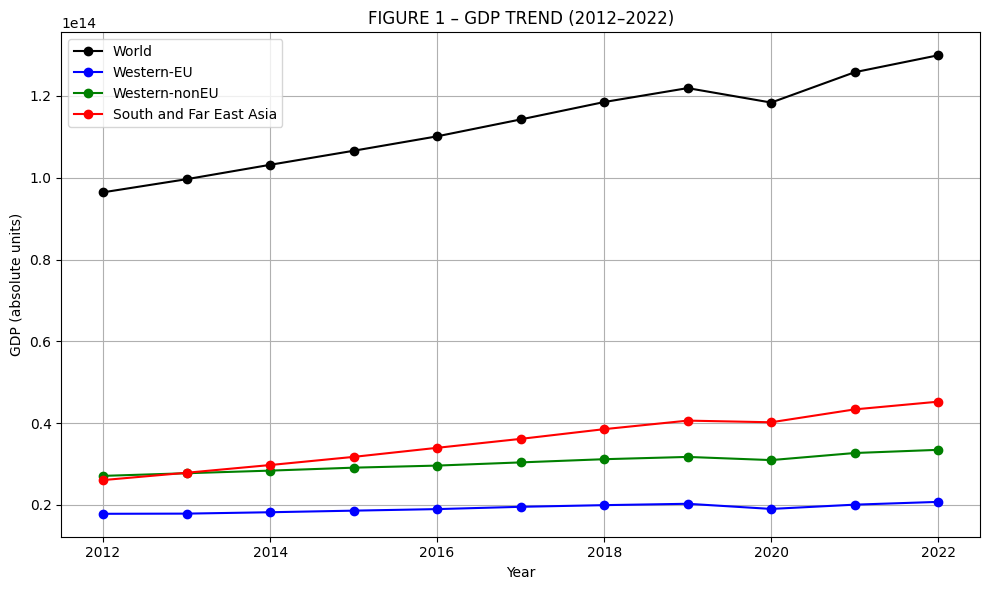

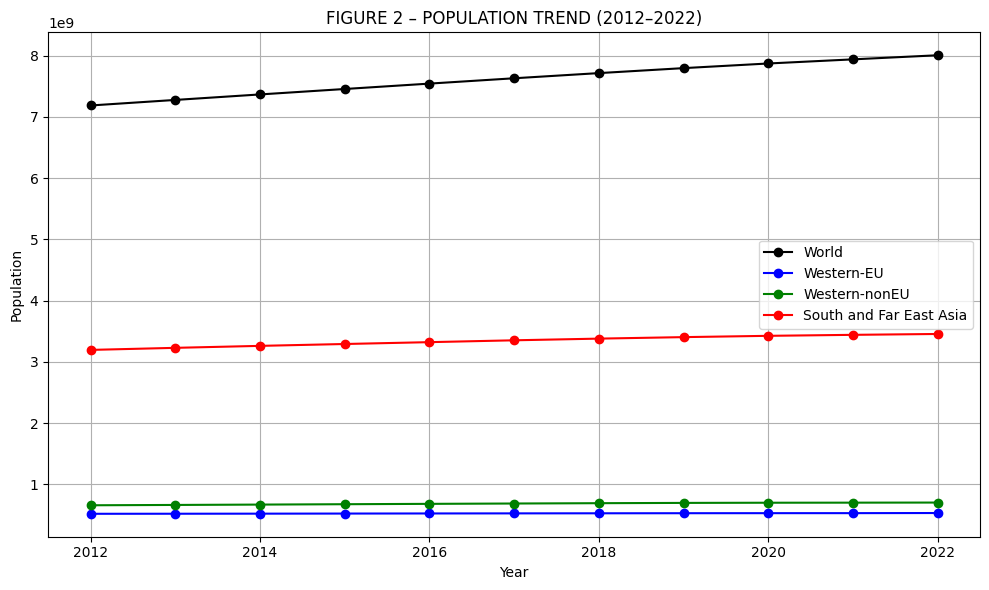

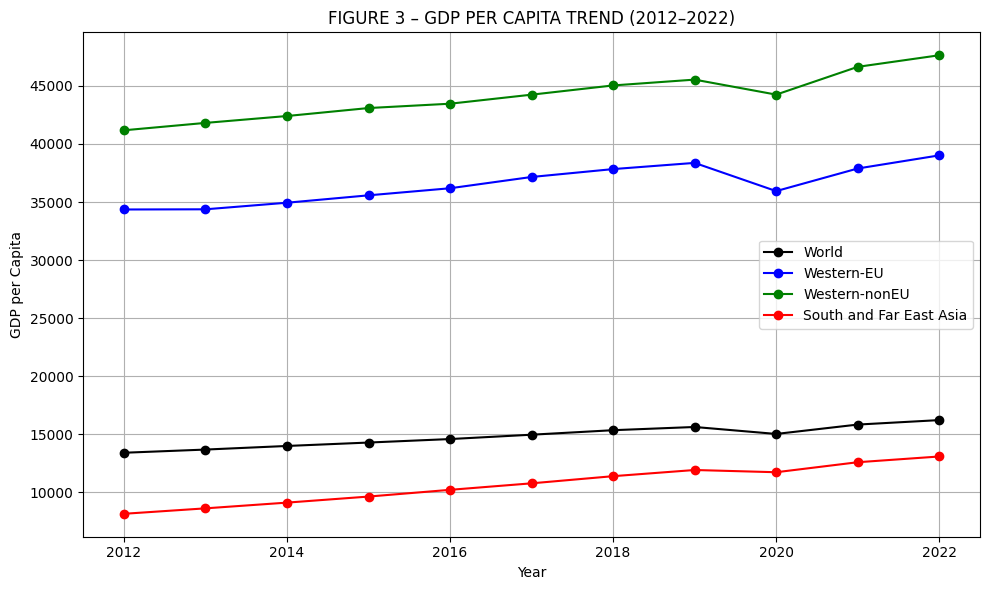

In [ ]:
# Graph no. 1  — GDP TREND

plt.figure(figsize=(10, 6))
for region in regions_of_interest:
    s = region_series(region, "gdp")
    plt.plot(s.index, s.values, marker='o', color=region_colors[region], label=region)

plt.title("FIGURE 1 – GDP TREND (2012–2022)")
plt.xlabel("Year")
plt.ylabel("GDP (absolute units)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Graph no. 2  — POPULATION TREND
plt.figure(figsize=(10, 6))
for region in regions_of_interest:
    s = region_series(region, "population")
    plt.plot(s.index, s.values, marker='o', color=region_colors[region], label=region)

plt.title("FIGURE 2 – POPULATION TREND (2012–2022)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Graph no. 3  — GDP PER CAPITA TREND
plt.figure(figsize=(10, 6))
for region in regions_of_interest:
    s = region_series(region, "gdp_per_capita")
    plt.plot(s.index, s.values, marker='o', color=region_colors[region], label=region)

plt.title("FIGURE 3 – GDP PER CAPITA TREND (2012–2022)")
plt.xlabel("Year")
plt.ylabel("GDP per Capita")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### **Vyhodnotenie trendov v makroekonomických ukazovateľoch**

Z vyššie zobrazených grafov je zrejmé, že dlhodobý trend v celosvetovom GDP je pozitívny (rastúci) pričom jednotlivé regióny vykazujú pomerne vysoké rozdiely v raste absolútneho GDP (s regiónom Western-EU na tom "horšom konci", pričom za najrýchlejšie rastúci región je pravdepodobne možné považovať región označený ako "Rest of the world", t.j. rozvíjajúce sa krajiny (keďže celkový rast pre celý svet je výrazne rýchlejší ako pre konkrétne regióny uvedené v tomto grafe).

Po odfiltrovaní faktoru rastu populácie (t.j. po prechode na "per_capita" sa už ale ekonomick situácia krajín regiónov "Western-EU" a "Western-nonEU" javí podstatne pozitívnejšie, s preukázateľne najvyšším GDP na obyvateľa a s pomerne vysokou mierou rastu tohto ukazovateľa.

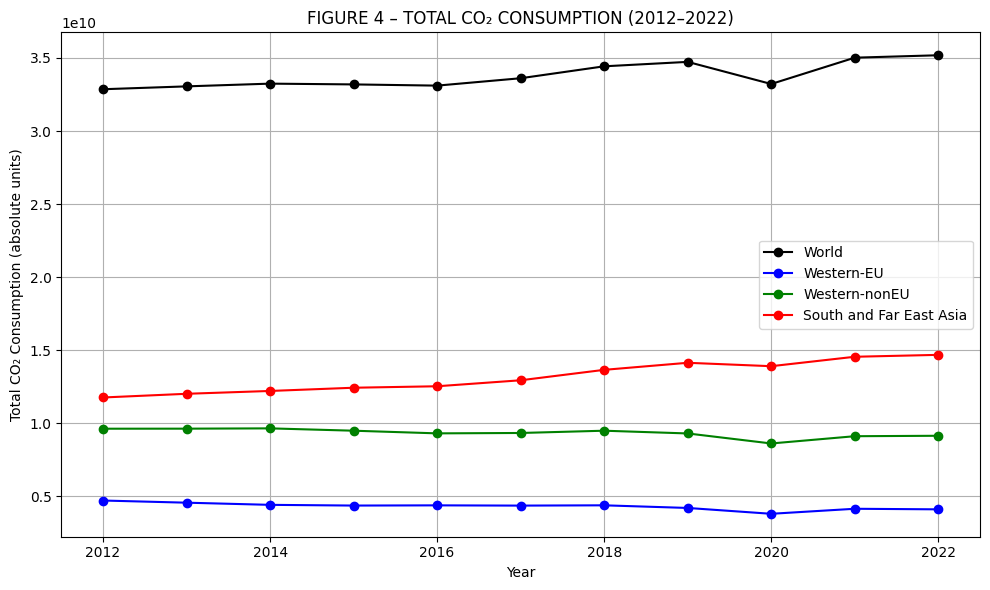

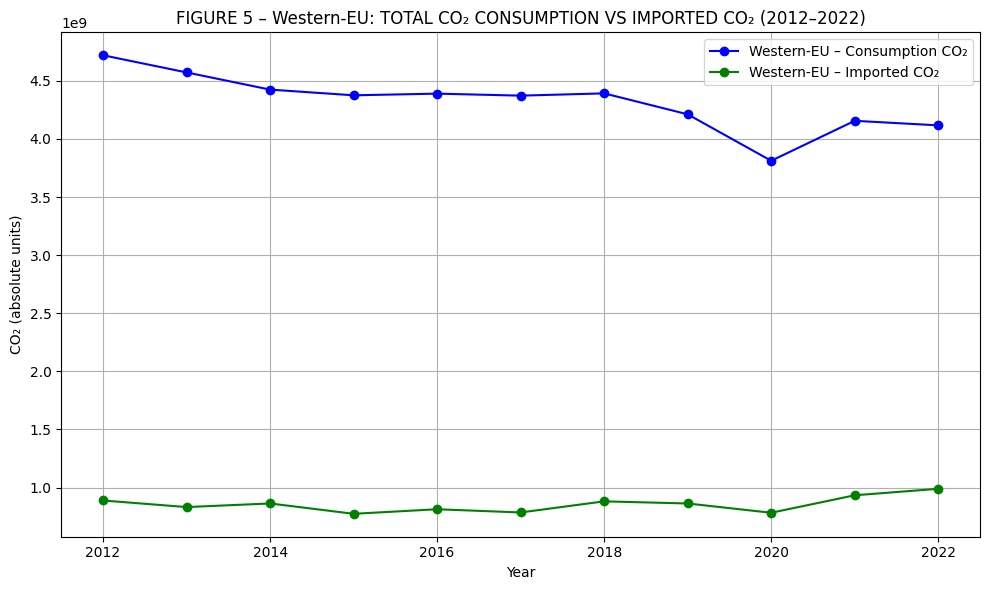

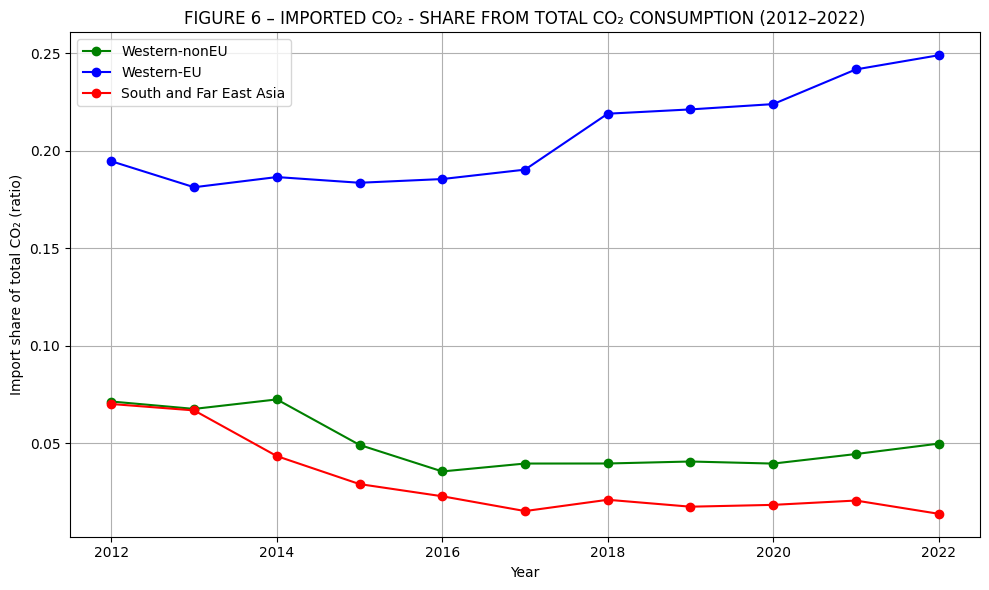

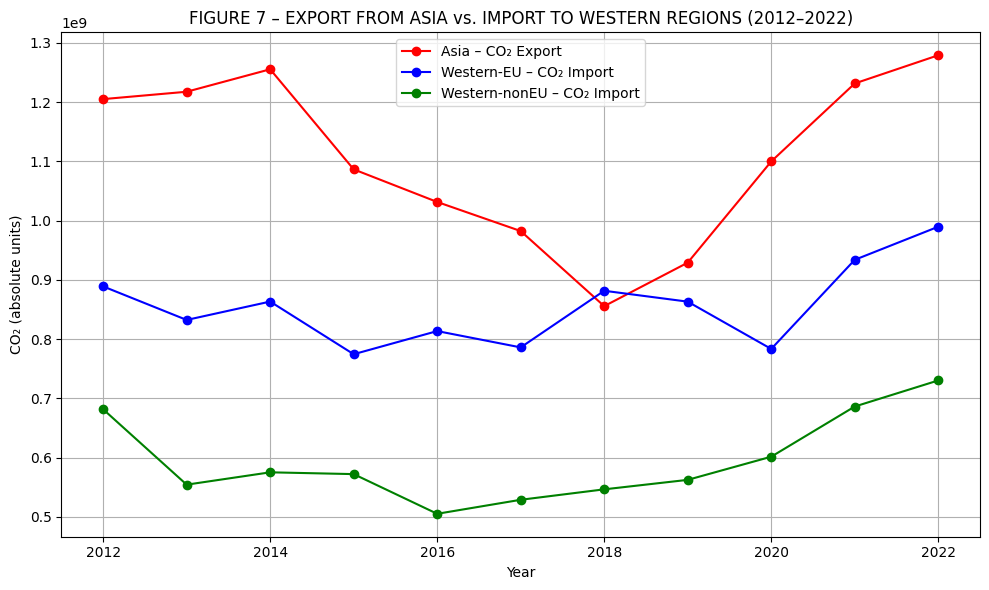

In [ ]:
# Graph no. 4  — TOTAL CO₂ CONSUMPTION
plt.figure(figsize=(10, 6))
for region in regions_of_interest:
    s = region_series(region, "consumption_co2_total")
    plt.plot(s.index, s.values, marker='o', color=region_colors[region], label=region)

plt.title("FIGURE 4 – TOTAL CO₂ CONSUMPTION (2012–2022)")
plt.xlabel("Year")
plt.ylabel("Total CO₂ Consumption (absolute units)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Graph no. 5  — Western-EU: TOTAL CO₂ CONSUMPTION VS IMPORTED CO₂
plt.figure(figsize=(10, 6))

west = df_2012_2022[df_2012_2022["Region"] == "Western-EU"]
west_cons = west.groupby("year")["consumption_co2_total"].sum()
west_imp = west.groupby("year")["import_co2_total"].sum()

plt.plot(west_cons.index, west_cons.values, marker='o', color="blue", label="Western-EU – Consumption CO₂")
plt.plot(west_imp.index, west_imp.values, marker='o', color="green", label="Western-EU – Imported CO₂")

plt.title("FIGURE 5 – Western-EU: TOTAL CO₂ CONSUMPTION VS IMPORTED CO₂ (2012–2022)")
plt.xlabel("Year")
plt.ylabel("CO₂ (absolute units)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Graph no. 6  — IMPORTED CO₂ - SHARE FROM TOTAL CO₂ CONSUMPTION
plt.figure(figsize=(10, 6))
for region in ["Western-nonEU", "Western-EU", "South and Far East Asia"]:
    s = df_2012_2022[df_2012_2022["Region"] == region] \
        .groupby("year")["import_to_overal_co2_ratio_gdp"].mean()
    plt.plot(s.index, s.values, marker='o', color=region_colors[region], label=region)

plt.title("FIGURE 6 – IMPORTED CO₂ - SHARE FROM TOTAL CO₂ CONSUMPTION (2012–2022)")
plt.xlabel("Year")
plt.ylabel("Import share of total CO₂ (ratio)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Graph no. 7 - EXPORT FROM ASIA vs. IMPORT TO WESTERN REGIONS
plt.figure(figsize=(10, 6))

asia_export = df_2012_2022[df_2012_2022["Region"] == "South and Far East Asia"] \
    .groupby("year")["export_co2_total"].sum()
west_eu_import = df_2012_2022[df_2012_2022["Region"] == "Western-EU"] \
    .groupby("year")["import_co2_total"].sum()
west_non_import = df_2012_2022[df_2012_2022["Region"] == "Western-nonEU"] \
    .groupby("year")["import_co2_total"].sum()

plt.plot(asia_export.index, asia_export.values, marker='o', color="red", label="Asia – CO₂ Export")
plt.plot(west_eu_import.index, west_eu_import.values, marker='o', color="blue", label="Western-EU – CO₂ Import")
plt.plot(west_non_import.index, west_non_import.values, marker='o', color="green", label="Western-nonEU – CO₂ Import")

plt.title("FIGURE 7 – EXPORT FROM ASIA vs. IMPORT TO WESTERN REGIONS (2012–2022)")
plt.xlabel("Year")
plt.ylabel("CO₂ (absolute units)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### **Vyhodnotenie trendov v absolútnych CO<sub>2</sub> emisiách a ich exporte / importe a záverečné vyhodnotenie**

Jedným z kľúčových zistení je skutočnosť, vyplývajúca z prvého grafu v tejto časti, že celkové množstvo celostvetových emisií CO<sub>2</sub> naďalej rastie. To isté platí aj pre región "South and Far East Asia", v ktorom taktiež celkové množstvo emisií CO<sub>2</sub> plynule rastie (aj keď o niečo pomalším tempom ako celosvetové emisie).

Na rozdiel od celého sveta a regiónu "South and Far East Asia" pre región "Western-EU" platí, že celkové emisie CO<sub>2</sub> v absolútnych číslach klesajú (čo je zrejmé z druhého grafu v tejto časti).

V rámci tejt časti je teda možné konštatovať jednoznačne pozitívný záver, že  celkové množstvo emisií CO<sub>2</sub> vyjadrené v absolútnych číslach sa  v rámci EÚ naďalej darí pomerne výrazne znižovať. Toto je pre EÚ najpodstatnejším pozitívnym zistením celej tejto analýzy.

V nadväznosti na tento pozitívny záver je potrebné ale jedným dychom uviesť aj najpodstatnejší negatívny záver tejto časti, že totiž celosvetové množstvo emisií  CO<sub>2</sub> vyjadrené v absolútnych číslach naopak aj naďalej rastie (a teda emisie CO<sub>2</sub> sa neznižujú ale naopak stále rastú). S ohľadom na neexistenciu hraníc pre šírenie CO<sub>2</sub> má tento negatívny záver podstatne väčšiu váhu ako čiastkový pozitívny záver vzťahujúci sa len na priestor EÚ.

V druhom grafe tejto časti je ale spolu s celkovou absolútnou spotrebou CO<sub>2</sub>  znázornený aj celkový import CO<sub>2</sub> do regiónu EÚ (v absolútnych číslach), pričom je zrejmé, že podiel importu na celkových emisiách tohto regiónu rastie.

Zreteľnejšie je to možné vidieť na ďalšom grafe tejto časti (treťom) v ktorom je znázornený import CO<sub>2</sub> do regiónu "Western-EU" (a aj do iných záujmových regiónov). Z tohto grafu je zrejmé, že podiel importovaných emisií CO<sub>2</sub> na celkovom množstve emisií (vypustenom resp. spotrebovanom na území daného štátu) v sledovanom období konštantne rastie, pričom tento trend predovšetkým po roku 2015 výrazne zrýchlil.

V porovnaní a v kontraste s uvedeným, podiel importu CO<sub>2</sub>  pri ostatných vyspelých štátoch ("Western-nonEU") naopak kontinuálne klesá.

Z uvedeného je teda zrejmé, že región EÚ je zatiaľ stále schopný aj naďalej znižovať celkové množstvo emisií CO<sub>2</sub>, uvedený trend je ale sprevádzaný spomaľovaním ekonomického rastu a rastúcou "CO<sub>2</sub> importnou"  závislosťou (t.j. rastúcim presunom výroby a s tým súvisiacich CO<sub>2</sub> emisií do iných regiónov).

V nadväznosti na uvedené je rovnako zaujímavé porovnanie celkového "CO<sub>2</sub>" exportu (v absolútnych číslach) z regiónu "South and Far East Asia" a celkového "CO<sub>2</sub> importu" (taktiež v absolútnych číslach) do regiónov "Western-EU" a "Western-nonEU", ktoré je znázornené v štvrtok grafe tejto časti. Z veľmi podobného tvaru krivky exportu a importu predovšetkým v posledných rokoch je možné vyvodiť záver (skôr hypotézu, keďže v skúmaných dátach nie sú k dispozícii exatkné údaje o konkrétnom smerovaní exportu a konkrétnom zdroji importu) o tom, že nárast exportu z regiónu "South and Far East Asia" je vyvolaný z podstatnej časti práve nárastom potreby importu imisií predovšetkým do regiónu "Western-EU". Inými slovami, presun "CO<sub>2</sub> náročnej" výroby z priestoru EÚ do iného regiónu, bez poklesu dopytu po produktov takejto výroby následne vyvoláva zvýšený dopyt po importe týchto produktov (so sprievodným importom emisií CO<sub>2</sub>).

Uvedený záver (ktorý by ale bolo potrebné podstatne podrobnejšie overiť) do veľkej miery povrdzuje v úvode vyslovenú hypotézu o čiastočnom presune emisií CO<sub>2</sub> do iných regiónov. Veľmi dôležitým zistením v tomto kontexte je pritom skutočnosť, že tento proces má predovšetkým v posledných rokoch zrýchľujúci charakter.
